In [0]:
from functools import reduce

import pandas as pd
import numpy as np
import optuna
import mlflow
from mlflow.models import infer_signature
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

from pyspark.sql.functions import col
from pyspark.sql import functions as F, Window
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import RegressionEvaluator

# PyTorch imports for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# TorchDistributor for distributed PyTorch training on Spark
from pyspark.ml.torch.distributor import TorchDistributor

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cpu
CUDA available: False


In [0]:
# Configuration for large-scale data (31M rows, 350 columns)
# Cluster: 6-12 workers, m5d.4xlarge (16 vCPU, 64GB RAM per node)

USE_SAMPLE = True  # Changed from True - now using full 31M rows
SAMPLE_FRACTION = 0.1  # Not used when USE_SAMPLE=False

# Undersampling configuration
USE_UNDERSAMPLING = False  # Set to True to balance training data via UNDERSAMPLING (reduce samples below log(15+1) threshold)
                           # Reduces below-threshold samples to match above-threshold count (50/50 balance)
                           # RECOMMENDED: Use USE_WEIGHTED_LOSS instead for better memory efficiency

# Weighted loss configuration (RECOMMENDED alternative to undersampling)
USE_WEIGHTED_LOSS = False  # Set to True to emphasize high-delay predictions in loss function
                          # Benefits: No memory overhead, no Spark errors, same effectiveness

# Bias correction configuration
USE_BIAS_CORRECTION = False  # Set to True to apply bias correction when converting from log scale to original scale

In [0]:
df = spark.read.parquet("dbfs:/student-groups/Group_03_01/data_gold.parquet").repartition(64)
print(f"Dataframe has {df.count()} rows and {len(df.columns)} columns.")

Dataframe has 30512480 rows and 151 columns.


In [0]:
df = df.withColumn("YEAR_MONTH", F.concat_ws("-", F.col("YEAR"), F.col("MONTH")))
keys = [row.YEAR_MONTH for row in df.select("YEAR_MONTH").distinct().collect()]
fractions = {k: SAMPLE_FRACTION for k in keys}
data_5y_sampled = df.sampleBy("YEAR_MONTH", fractions, seed=42)

if USE_SAMPLE: 
    data = data_5y_sampled
else:
    data = df

print(data.count())

3052710


In [0]:
import requests

url = "https://raw.githubusercontent.com/bemilyz/mids261_final_project_grp3_1_2025/main/Feature_Selection%20-%20complete_num.csv"
local_tmp_path = "/tmp/Feature_Selection.csv"
dbfs_path = "dbfs:/student-groups/Group_3_1/Feature_Selection.csv"

response = requests.get(url)
with open(local_tmp_path, "wb") as f:
    f.write(response.content)

dbutils.fs.cp(
    f"file:{local_tmp_path}",
    dbfs_path
)

features_metadata = (
    spark.read.format("csv")
    .option("header", True)
    .load(dbfs_path)
)

# csv_path = 'file:/Workspace/Users/fulingw@berkeley.edu/data/Feature_Selection.csv'
# features_metadata = spark.read.option("header", "true").csv(csv_path)

display(features_metadata)

Name,Null_Count,FeatureType,Category,Select,Reason,_c6
ARR_TIME,0,num,base,No,Data leakage,null
CANCELLED,0,num,base,No,All canceled will be dropped,null
CRS_ARR_TIME,0,num,base,Yes,null,null
CRS_DEP_TIME,0,num,base,Yes,null,null
DAY_OF_MONTH,0,num,base,No,Use DAY_OF_MONTH_cos/_sin,null
DAY_OF_MONTH_cos,0,num,engineered,Yes,null,null
DAY_OF_MONTH_sin,0,num,engineered,Yes,null,null
DAY_OF_WEEK,0,num,base,No,Use DAY_OF_WEEK_cos/sin,null
DAY_OF_WEEK_cos,0,num,engineered,Yes,null,null
DAY_OF_WEEK_sin,0,num,engineered,Yes,null,null


In [0]:
target_var = 'Log_DEP_DELAY'  # Changed from 'DEP_DELAY_NEW' to use log-transformed target

num_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="num")).select('Name').toPandas()['Name'].to_list()

# Need one-hot emcoding
cat_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="cat")).select('Name').toPandas()['Name'].to_list()

# Features that are already one-hot encoded 
ohe_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="ohe")).select('Name').toPandas()['Name'].to_list()

# Embedding features
embedding_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="embedding")).select('Name').toPandas()['Name'].to_list()

print(f"Total number of features (pre one-hot): {len(num_features) + len(cat_features) + len(ohe_features) + len(embedding_features)}")
print(f"Numerical features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")
print(f"OHE features: {len(ohe_features)}")
print(f"Embedding features: {len(embedding_features)}")

Total number of features (pre one-hot): 122
Numerical features: 100
Categorical features: 4
OHE features: 10
Embedding features: 8


## Model Prep

In [0]:
# Numerical features: assemble and scale
num_assembler = VectorAssembler(
    inputCols=num_features,
    outputCol="num_vec"
)

scaler = StandardScaler(
    inputCol="num_vec",
    outputCol="num_scaled",
    withMean=True,
    withStd=True
)

# Categorical features: index and one-hot encode
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"  # avoid failures on unseen/NULLs
    )
    for c in cat_features
]

indexed_cols = [f"{c}_idx" for c in cat_features]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=[f"{c}_oh" for c in cat_features]
)

encoded_cols = [f"{c}_oh" for c in cat_features]

# Embedding features: index only (no one-hot encoding)
# These will be used as integer indices for embedding layers
embedding_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in embedding_features
]

embedding_indexed_cols = [f"{c}_idx" for c in embedding_features]

# Assemble non-embedding features into a single vector
feature_assembler = VectorAssembler(
    inputCols=["num_scaled"] + encoded_cols + ohe_features,
    outputCol="features"
)

# Create preprocessing pipeline (without model)
preprocessing_pipeline = Pipeline(stages=[
    num_assembler,
    scaler,
    *indexers,
    encoder,
    *embedding_indexers,  # Add embedding indexers
    feature_assembler
])

print(f"Preprocessing pipeline created with {len(embedding_features)} embedding features")

Preprocessing pipeline created with 8 embedding features


In [0]:
def prepare_data_for_pytorch(spark_df, label_col=target_var):
    """
    Convert preprocessed Spark DataFrame to PyTorch tensors.
    Handles both dense features and embedding indices.
    
    Args:
        spark_df: Spark DataFrame with 'features' column, embedding index columns, and label column
        label_col: Name of the label column
    
    Returns:
        X_dense: Dense feature tensor (numerical + one-hot encoded)
        X_embeddings: Dictionary of embedding index tensors {feature_name: tensor}
        y: Label tensor
    """
    # Select needed columns
    select_cols = ["features"] + embedding_indexed_cols + [label_col]
    data_pd = spark_df.select(select_cols).toPandas()
    
    # Convert dense features (numerical + one-hot encoded)
    X_dense = np.vstack([row.features.toArray() for row in data_pd.itertuples()])
    X_dense_tensor = torch.FloatTensor(X_dense)
    
    # Convert embedding indices to integer tensors
    X_embeddings = {}
    for emb_col in embedding_indexed_cols:
        # Extract the feature name (remove '_idx' suffix)
        feat_name = emb_col.replace('_idx', '')
        # Convert to long tensor (required for embedding layers)
        X_embeddings[feat_name] = torch.LongTensor(data_pd[emb_col].values.astype(int))
    
    # Convert labels
    y = data_pd[label_col].values
    y_tensor = torch.FloatTensor(y)
    
    print(f"Converted {len(X_dense_tensor):,} samples to PyTorch tensors")
    print(f"Dense features shape: {X_dense_tensor.shape}")
    print(f"Embedding features: {len(X_embeddings)}")
    
    return X_dense_tensor, X_embeddings, y_tensor

print("Data conversion function defined (with embedding support)")

Data conversion function defined (with embedding support)


## Helper functions for modeling

In [0]:
# Embedding scaling factor (α) - single hyperparameter to tune embedding dimensions
# α = 0.75: Smaller embeddings (faster training, less memory)
# α = 1.0:  Base embeddings (balanced)
# α = 1.5:  Larger embeddings (more capacity, slower training)
EMBEDDING_SCALE_FACTOR = 1.0  # Default: α = 1.0

def get_embedding_config(spark_df, embedding_features, scale_factor=1.0):
    """
    Calculate embedding dimensions for each embedding feature using scaling factor.
    
    Formula:
        Base Dimension (D_base) = round(C^0.25) where C is vocabulary size
        Final Dimension (D_final) = round(D_base × α) where α is scale_factor
    
    Args:
        spark_df: Spark DataFrame with the embedding features
        embedding_features: List of feature names to create embeddings for
        scale_factor: Scaling factor (α) to adjust embedding dimensions (default: 1.0)
    
    Returns:
        Dictionary with embedding configurations {feature_name: (vocab_size, embedding_dim)}
    """
    embedding_config = {}
    
    for feat in embedding_features:
        # Get vocabulary size
        # +2 because: (1) StringIndexer creates indices 0 to n-1, and (2) handleInvalid="keep" adds one more index for unknown values
        vocab_size = spark_df.select(feat).distinct().count() + 2
        
        # Calculate base dimension using C^0.25 formula
        base_dim = round(vocab_size ** 0.25)
        
        # Apply scaling factor
        final_dim = max(round(base_dim * scale_factor), 2)  # Minimum 2 dimensions
        
        embedding_config[feat] = (vocab_size, final_dim)
    
    return embedding_config

# Print the options 
EMBEDDING_SCALE_FACTOR_options = [0.75, 1.0, 1.5]

# Calculate configurations for all alpha values
configs = {alpha: get_embedding_config(data, embedding_features, alpha) for alpha in EMBEDDING_SCALE_FACTOR_options}

# Print table
print(f"{'Feature Name':<25} {'Vocab (C)':<12} {'Base Dim':<12}" + "".join(f" {'D (α=' + str(a) + ')':<12}" for a in EMBEDDING_SCALE_FACTOR_options))
print(f"{'':25} {'':12} {'(C^0.25)':<12}" + " " * (12 * len(EMBEDDING_SCALE_FACTOR_options)))
print("-" * 95)

total_base_dim = 0
total_dims = {alpha: 0 for alpha in EMBEDDING_SCALE_FACTOR_options}

for feat in embedding_features:
    vocab_size, _ = configs[EMBEDDING_SCALE_FACTOR_options[0]][feat]
    base_dim = round(vocab_size ** 0.25)
    total_base_dim += base_dim
    
    row = f"{feat:<25} {vocab_size:<12} {base_dim:<12}"
    for alpha in EMBEDDING_SCALE_FACTOR_options:
        dim = configs[alpha][feat][1]
        total_dims[alpha] += dim
        row += f" {dim:<12}"
    print(row)

print("-" * 95)
print(f"{'Total Concat Dim:':<25} {'':12} {total_base_dim:<12}" + "".join(f" {total_dims[a]:<12}" for a in EMBEDDING_SCALE_FACTOR_options))

embedding_config = get_embedding_config(data, embedding_features, EMBEDDING_SCALE_FACTOR)

Feature Name              Vocab (C)    Base Dim     D (α=0.75)   D (α=1.0)    D (α=1.5)   
                                       (C^0.25)                                        
-----------------------------------------------------------------------------------------------
OP_CARRIER_FL_NUM         7090         9            7            9            14          
TAIL_NUM                  7839         9            7            9            14          
OP_CARRIER                21           2            2            2            3           
ORIGIN                    343          4            3            4            6           
ORIGIN_STATE_ABR          53           3            2            3            4           
DEST                      353          4            3            4            6           
DEST_STATE_ABR            53           3            2            3            4           
ORIGIN_PREV               344          4            3            4            6         

In [0]:
def create_mlp_with_embeddings(dense_input_dim, embedding_config, hidden_dims=[256, 128, 64], 
                               dropout_rate=0.3, use_output_activation=True):
    """
    Create a Multi-Layer Perceptron with Embedding Layers (functional approach).
    Returns a model and embedding layers as separate components.
    
    Args:
        dense_input_dim: Dimension of dense features (numerical + one-hot encoded)
        embedding_config: Dict {feature_name: (vocab_size, embedding_dim)}
        hidden_dims: List of hidden layer dimensions
        dropout_rate: Dropout probability for regularization
        use_output_activation: If True, adds Softplus to output
    
    Returns:
        embeddings: nn.ModuleDict of embedding layers
        mlp: nn.Sequential model for the feedforward network
        embedding_features: List of embedding feature names (for forward pass)
    """
    # Create embedding layers
    embeddings = nn.ModuleDict({
        feat_name: nn.Embedding(vocab_size, emb_dim)
        for feat_name, (vocab_size, emb_dim) in embedding_config.items()
    })
    
    embedding_features = list(embedding_config.keys())
    
    # Calculate total input dimension
    total_embedding_dim = sum(emb_dim for _, emb_dim in embedding_config.values())
    total_input_dim = dense_input_dim + total_embedding_dim
    
    # Build MLP layers
    layers = []
    prev_dim = total_input_dim
    
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.Dropout(dropout_rate))
        prev_dim = hidden_dim
    
    # Output layer
    layers.append(nn.Linear(prev_dim, 1))
    
    # Optional output activation
    if use_output_activation:
        layers.append(nn.Softplus())
    
    mlp = nn.Sequential(*layers)
    
    return embeddings, mlp, embedding_features


def forward_pass(embeddings, mlp, embedding_features, x_dense, x_embeddings):
    """
    Functional forward pass for model with embeddings.
    
    Args:
        embeddings: nn.ModuleDict of embedding layers
        mlp: nn.Sequential model
        embedding_features: List of embedding feature names
        x_dense: Dense features tensor [batch_size, dense_input_dim]
        x_embeddings: Dict of embedding index tensors {feature_name: [batch_size]}
    
    Returns:
        predictions: [batch_size, 1]
    """
    # Process embeddings
    embedded_features = []
    for feat_name in embedding_features:
        emb = embeddings[feat_name](x_embeddings[feat_name])
        embedded_features.append(emb)
    
    # Concatenate all embeddings with dense features
    if embedded_features:
        embeddings_concat = torch.cat(embedded_features, dim=1)
        x = torch.cat([x_dense, embeddings_concat], dim=1)
    else:
        x = x_dense
    
    # Pass through MLP
    output = mlp(x)
    return output

print("Functional PyTorch MLP model with embeddings defined")

Functional PyTorch MLP model with embeddings defined


In [0]:
def inverse_log_transform(y_log, sigma_squared=0.0, bias_correction=False):
    """
    Convert log-transformed predictions back to original scale.
    Applies bias correction to address underprediction bias.
    Includes overflow protection for numerical stability.
    
    OPTIMIZED: PyTorch-only implementation (no NumPy conversion overhead).
    
    Args:
        y_log: Predictions in log space (torch tensor)
        sigma_squared: Variance of residuals in log space (for bias correction)
        bias_correction: Whether to apply bias correction (default: False)
    
    Returns:
        y: Predictions in original scale (minutes) as torch tensor
    
    Formula:
        Without correction: y = exp(y_log) - 1
        With correction: y = exp(y_log + sigma^2/2) - 1
    
    Note:
        Log_DEP_DELAY should be in range [0, ~8] for log(delay+1).
        Predictions outside this range are clipped to prevent overflow.
    """
    if bias_correction and sigma_squared > 0:
        # Bias-corrected inverse transform
        exponent = y_log + sigma_squared / 2
    else:
        # Standard inverse transform
        exponent = y_log
    
    # Clip to [-1, 9] for safety:
    #   exp(9) - 1 = 8,102 minutes (~5.6 days) - reasonable max delay
    #   exp(-1) - 1 = -0.63 minutes -> clipped to 0 later
    exponent = torch.clamp(exponent, -1, 9)
    
    # Apply inverse transform
    y = torch.exp(exponent) - 1
    
    # Ensure non-negative (delays can't be negative)
    y = torch.maximum(y, torch.zeros_like(y))
    
    return y

print("Log inverse transform function defined (PyTorch-only, optimized)")

Log inverse transform function defined (PyTorch-only, optimized)


In [0]:
def train_pytorch_distributed(model_params, training_params, train_data, val_data, embedding_config_param, use_bias_correction=None, use_weighted_loss=True, loss_weight_alpha=0.5):
    """
    Training function for PyTorch model with embedding layers.
    Uses MSE (or weighted MSE) as the loss function for training (stable gradients).
    Reports RMSE, MAE, and MAE_mod in original scale (minutes) with optional bias-corrected inverse transform.
    
    MAE_mod: Modified MAE that zeros out values < 15 minutes before calculating error.
    This metric is used for early stopping and model selection.
    
    OPTIMIZED: Uses PyTorch tensors throughout (no NumPy) for 7-12 seconds speedup per epoch.
    
    Args:
        model_params: Dict with 'hidden_dims' and 'dropout_rate'
        training_params: Dict with 'learning_rate', 'batch_size', 'num_epochs', 'patience', 'weight_decay'
        train_data: Tuple of (X_dense, X_embeddings, y) where X_embeddings is dict of embedding tensors
        val_data: Tuple of (X_dense, X_embeddings, y)
        embedding_config_param: Dict {feature_name: (vocab_size, embedding_dim)}
        use_bias_correction: Whether to use bias correction (if None, uses global USE_BIAS_CORRECTION)
        use_weighted_loss: Whether to use weighted MSE loss (emphasizes high delays)
        loss_weight_alpha: Weight increase rate for weighted loss (default: 0.5)
    
    Returns:
        Dict with train/val metrics for best epoch: 'train_rmse', 'train_mae', 'train_mae_mod',
        'val_rmse', 'val_mae', 'val_mae_mod', 'embeddings_state', 'mlp_state', 'dense_input_dim', 'model_params',
        'train_rmse_history', 'val_rmse_history', 'train_mae_history', 'val_mae_history',
        'train_mae_mod_history', 'val_mae_mod_history' (lists per epoch)
    """
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader
    
    # Use global USE_BIAS_CORRECTION if not explicitly provided
    if use_bias_correction is None:
        try:
            use_bias_correction = USE_BIAS_CORRECTION
        except NameError:
            use_bias_correction = False  # Default to False if not defined
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Unpack data (already PyTorch tensors from prepare_data_for_pytorch)
    X_train_dense, X_train_embeddings, y_train = train_data
    X_val_dense, X_val_embeddings, y_val = val_data
    
    # Custom dataset class for embeddings
    class EmbeddingDataset(torch.utils.data.Dataset):
        def __init__(self, X_dense, X_embeddings, y):
            self.X_dense = X_dense
            self.X_embeddings = X_embeddings
            self.y = y
            self.embedding_features = list(X_embeddings.keys())
        
        def __len__(self):
            return len(self.X_dense)
        
        def __getitem__(self, idx):
            dense = self.X_dense[idx]
            embeddings = {feat: self.X_embeddings[feat][idx] for feat in self.embedding_features}
            label = self.y[idx]
            return dense, embeddings, label
    
    # Create datasets
    train_dataset = EmbeddingDataset(X_train_dense, X_train_embeddings, y_train)
    val_dataset = EmbeddingDataset(X_val_dense, X_val_embeddings, y_val)
    
    # Batch size
    batch_size = training_params.get('batch_size', 4096)
    
    # Custom collate function for embedding data
    def collate_fn(batch):
        dense_batch = torch.stack([item[0] for item in batch])
        embedding_features = list(batch[0][1].keys())
        embeddings_batch = {feat: torch.stack([item[1][feat] for item in batch]) for feat in embedding_features}
        labels_batch = torch.stack([item[2] for item in batch])
        return dense_batch, embeddings_batch, labels_batch
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # Create model using functional approach with embeddings
    dense_input_dim = X_train_dense.shape[1]
    embeddings, mlp, embedding_features = create_mlp_with_embeddings(
        dense_input_dim=dense_input_dim,
        embedding_config=embedding_config_param,
        hidden_dims=model_params['hidden_dims'],
        dropout_rate=model_params['dropout_rate']
    )
    
    # Move to device
    embeddings = embeddings.to(device)
    mlp = mlp.to(device)
    
    # Optimizer - combine parameters from embeddings and mlp
    all_params = list(embeddings.parameters()) + list(mlp.parameters())
    optimizer = optim.Adam(
        all_params, 
        lr=training_params['learning_rate'], 
        weight_decay=training_params.get('weight_decay', 1e-5)
    )
    
    # Learning rate scheduler - now uses MAE_mod as the metric
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    # Training loop - track best metrics and history
    best_val_mae_mod = float('inf')  # PRIMARY METRIC for early stopping
    best_val_rmse = float('inf')
    best_val_mae = float('inf')
    best_train_rmse = float('inf')
    best_train_mae = float('inf')
    best_train_mae_mod = float('inf')
    best_embeddings_state = None
    best_mlp_state = None
    patience_counter = 0
    
    # History tracking
    train_rmse_history = []
    val_rmse_history = []
    train_mae_history = []
    val_mae_history = []
    train_mae_mod_history = []
    val_mae_mod_history = []
    
    for epoch in range(training_params['num_epochs']):
        # Training phase
        embeddings.train()
        mlp.train()
        train_loss = 0.0
        
        # OPTIMIZATION: Preallocate PyTorch tensors instead of lists
        train_predictions_log = torch.zeros(len(train_dataset), device='cpu', dtype=torch.float32)
        train_actuals_log = torch.zeros(len(train_dataset), device='cpu', dtype=torch.float32)
        
        idx = 0
        for batch_dense, batch_embeddings, batch_y in train_loader:
            batch_dense = batch_dense.to(device)
            batch_embeddings = {k: v.to(device) for k, v in batch_embeddings.items()}
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = forward_pass(embeddings, mlp, embedding_features, batch_dense, batch_embeddings).squeeze()
            
            # Use weighted or standard MSE loss for training
            if use_weighted_loss:
                loss = weighted_mse_loss(outputs, batch_y, threshold=2.7726, alpha=loss_weight_alpha)
            else:
                loss = nn.functional.mse_loss(outputs, batch_y)
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item() * batch_dense.size(0)
            
            # OPTIMIZATION: Direct tensor indexing instead of append + concatenate
            batch_size_actual = outputs.size(0)
            train_predictions_log[idx:idx+batch_size_actual] = outputs.detach().cpu()
            train_actuals_log[idx:idx+batch_size_actual] = batch_y.cpu()
            idx += batch_size_actual
        
        train_loss /= len(train_dataset)
        
        # Validation phase - ALWAYS use unweighted MSE for validation
        embeddings.eval()
        mlp.eval()
        val_mse = 0.0
        
        # OPTIMIZATION: Preallocate PyTorch tensors for validation
        val_predictions_log = torch.zeros(len(val_dataset), device='cpu', dtype=torch.float32)
        val_actuals_log = torch.zeros(len(val_dataset), device='cpu', dtype=torch.float32)
        
        idx = 0
        with torch.no_grad():
            for batch_dense, batch_embeddings, batch_y in val_loader:
                batch_dense = batch_dense.to(device)
                batch_embeddings = {k: v.to(device) for k, v in batch_embeddings.items()}
                batch_y = batch_y.to(device)
                outputs = forward_pass(embeddings, mlp, embedding_features, batch_dense, batch_embeddings).squeeze()
                
                # Always use unweighted MSE for validation
                loss = nn.functional.mse_loss(outputs, batch_y)
                val_mse += loss.item() * batch_dense.size(0)
                
                # OPTIMIZATION: Direct tensor indexing
                batch_size_actual = outputs.size(0)
                val_predictions_log[idx:idx+batch_size_actual] = outputs.cpu()
                val_actuals_log[idx:idx+batch_size_actual] = batch_y.cpu()
                idx += batch_size_actual
        
        val_mse /= len(val_dataset)
        
        # OPTIMIZATION: Calculate sigma_squared in PyTorch if bias correction is enabled
        if use_bias_correction:
            val_log_residuals = val_actuals_log - val_predictions_log
            val_log_residual_variance = torch.var(val_log_residuals).item()
        else:
            val_log_residual_variance = 0.0  # Not used, skip calculation
        
        # OPTIMIZATION: Apply inverse transform - stays in PyTorch (no conversion)
        train_predictions_original = inverse_log_transform(
            train_predictions_log, 
            sigma_squared=val_log_residual_variance if use_bias_correction else 0.0, 
            bias_correction=use_bias_correction
        )
        train_actuals_original = inverse_log_transform(train_actuals_log, sigma_squared=0.0, bias_correction=False)
        val_predictions_original = inverse_log_transform(
            val_predictions_log, 
            sigma_squared=val_log_residual_variance if use_bias_correction else 0.0, 
            bias_correction=use_bias_correction
        )
        val_actuals_original = inverse_log_transform(val_actuals_log, sigma_squared=0.0, bias_correction=False)
        
        # OPTIMIZATION: Compute standard metrics in PyTorch - UNWEIGHTED RMSE for evaluation
        train_rmse = torch.sqrt(torch.mean((train_actuals_original - train_predictions_original) ** 2)).item()
        val_rmse = torch.sqrt(torch.mean((val_actuals_original - val_predictions_original) ** 2)).item()
        train_mae = torch.mean(torch.abs(train_actuals_original - train_predictions_original)).item()
        val_mae = torch.mean(torch.abs(val_actuals_original - val_predictions_original)).item()
        
        # NEW: Compute MAE_mod - zero out values < 15 minutes before calculating MAE
        threshold = 15.0  # minutes
        
        # Train MAE_mod
        train_actuals_mod = torch.where(train_actuals_original < threshold, 
                                        torch.zeros_like(train_actuals_original), 
                                        train_actuals_original)
        train_predictions_mod = torch.where(train_predictions_original < threshold, 
                                            torch.zeros_like(train_predictions_original), 
                                            train_predictions_original)
        train_mae_mod = torch.mean(torch.abs(train_actuals_mod - train_predictions_mod)).item()
        
        # Val MAE_mod
        val_actuals_mod = torch.where(val_actuals_original < threshold, 
                                      torch.zeros_like(val_actuals_original), 
                                      val_actuals_original)
        val_predictions_mod = torch.where(val_predictions_original < threshold, 
                                          torch.zeros_like(val_predictions_original), 
                                          val_predictions_original)
        val_mae_mod = torch.mean(torch.abs(val_actuals_mod - val_predictions_mod)).item()
        
        # Track history
        train_rmse_history.append(train_rmse)
        val_rmse_history.append(val_rmse)
        train_mae_history.append(train_mae)
        val_mae_history.append(val_mae)
        train_mae_mod_history.append(train_mae_mod)
        val_mae_mod_history.append(val_mae_mod)
        
        # Scheduler now uses MAE_mod
        scheduler.step(val_mae_mod)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{training_params['num_epochs']}: "
              f"Loss: {train_loss:.4f} | "
              f"Train MAE: {train_mae:.2f} | "
              f"Val MAE: {val_mae:.2f} | "
              f"Train MAE_mod: {train_mae_mod:.2f} | "
              f"Val MAE_mod: {val_mae_mod:.2f} | "
              f"Train RMSE: {train_rmse:.2f} min | "
              f"Val RMSE: {val_rmse:.2f} min | "
              f"LR: {current_lr:.6f}")
        
        # Early stopping - NOW USES MAE_mod AS PRIMARY METRIC
        if val_mae_mod < best_val_mae_mod:
            best_val_mae_mod = val_mae_mod
            best_val_rmse = val_rmse
            best_val_mae = val_mae
            best_train_rmse = train_rmse
            best_train_mae = train_mae
            best_train_mae_mod = train_mae_mod
            patience_counter = 0
            best_embeddings_state = embeddings.state_dict()
            best_mlp_state = mlp.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= training_params.get('patience', 5):
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Return metrics, model state, and history
    return {
        'train_rmse': best_train_rmse,
        'train_mae': best_train_mae,
        'train_mae_mod': best_train_mae_mod,
        'val_rmse': best_val_rmse,
        'val_mae': best_val_mae,
        'val_mae_mod': best_val_mae_mod,
        'embeddings_state': best_embeddings_state,
        'mlp_state': best_mlp_state,
        'dense_input_dim': dense_input_dim,
        'model_params': model_params,
        'embedding_config': embedding_config_param,
        'train_rmse_history': train_rmse_history,
        'val_rmse_history': val_rmse_history,
        'train_mae_history': train_mae_history,
        'val_mae_history': val_mae_history,
        'train_mae_mod_history': train_mae_mod_history,
        'val_mae_mod_history': val_mae_mod_history
    }

print("Training function updated - MAE_mod metric added (zeros values < 15 min) and set as evaluation metric")

Training function updated - MAE_mod metric added (zeros values < 15 min) and set as evaluation metric


In [0]:
# Weighted MSE Loss Function (Functional Approach)
# Gives higher weight to samples with larger delays (higher log values)
# This replaces oversampling by adjusting the loss function instead

import torch

def weighted_mse_loss(predictions, targets, threshold=2.7726, alpha=0.5):
    """
    Weighted MSE Loss that emphasizes errors on high-delay samples.
    
    Weight function: w(y) = 1 + alpha * max(0, y - threshold)
    
    For delays below threshold: weight = 1.0 (normal MSE)
    For delays above threshold: weight increases linearly with delay magnitude
    
    Args:
        predictions: Model predictions (log scale) - torch.Tensor
        targets: Ground truth labels (log scale) - torch.Tensor
        threshold: Log delay value above which to increase weights (default: log(15+1) = 2.77)
    
    Returns:
        Weighted MSE loss (scalar tensor)
    """
    # Compute squared errors
    squared_errors = (predictions - targets) ** 2
    
    # Compute weights based on target values
    # Weight = 1 + alpha * max(0, target - threshold)
    weights = 1.0 + alpha * torch.clamp(targets - threshold, min=0.0)
    
    # Apply weights to squared errors
    weighted_squared_errors = weights * squared_errors
    
    # Return mean weighted loss
    return weighted_squared_errors.mean()

# Test the weighted loss function
print("\nExample weights for different delay values:")
print(f"{'Delay (min)':<15} {'Log Value':<12} {'Weight (α=0.5)':<18} {'Weight (α=0.75)':<18} {'Weight (α=1.0)'}")
print("-" * 80)

test_delays = [0, 5, 10, 15, 30, 60, 120, 240]
threshold = 2.7726  # log(15+1)

for delay in test_delays:
    log_val = torch.log(torch.tensor(delay + 1.0))
    
    # Calculate weights for different alpha values
    weight_05 = 1.0 + 0.5 * max(0.0, log_val.item() - threshold)
    weight_75 = 1.0 + 0.75 * max(0.0, log_val.item() - threshold)
    weight_10 = 1.0 + 1.0 * max(0.0, log_val.item() - threshold)
    
    print(f"{delay:<15} {log_val.item():<12.4f} {weight_05:<18.4f} {weight_75:<18.4f} {weight_10:.4f}")



Example weights for different delay values:
Delay (min)     Log Value    Weight (α=0.5)     Weight (α=0.75)    Weight (α=1.0)
--------------------------------------------------------------------------------
0               0.0000       1.0000             1.0000             1.0000
5               1.7918       1.0000             1.0000             1.0000
10              2.3979       1.0000             1.0000             1.0000
15              2.7726       1.0000             1.0000             1.0000
30              3.4340       1.3307             1.4960             1.6614
60              4.1109       1.6691             2.0037             2.3383
120             4.7958       2.0116             2.5174             3.0232
240             5.4848       2.3561             3.0341             3.7122


In [0]:
def evaluate_model_on_test_set(embeddings, mlp, embedding_features, test_data, batch_size=4096, use_bias_correction=False):
    """
    Evaluate a trained PyTorch model on a test set.
    
    Args:
        embeddings: Trained embedding layers (nn.ModuleDict)
        mlp: Trained MLP model (nn.Sequential)
        embedding_features: List of embedding feature names
        test_data: Tuple of (X_dense, X_embeddings, y) where X_embeddings is dict of embedding tensors
        batch_size: Batch size for inference (default: 4096)
        use_bias_correction: Whether to apply bias correction in inverse transform
    
    Returns:
        Dict with test metrics: 'test_rmse', 'test_mae', 'test_mae_mod',
        'test_predictions_original', 'test_actuals_original'
    """
    import torch
    from torch.utils.data import DataLoader
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    embeddings = embeddings.to(device)
    mlp = mlp.to(device)
    embeddings.eval()
    mlp.eval()
    
    # Unpack test data
    X_test_dense, X_test_embeddings, y_test = test_data
    
    # Custom dataset class for embeddings
    class EmbeddingDataset(torch.utils.data.Dataset):
        def __init__(self, X_dense, X_embeddings, y):
            self.X_dense = X_dense
            self.X_embeddings = X_embeddings
            self.y = y
            self.embedding_features = list(X_embeddings.keys())
        
        def __len__(self):
            return len(self.X_dense)
        
        def __getitem__(self, idx):
            dense = self.X_dense[idx]
            embeddings = {feat: self.X_embeddings[feat][idx] for feat in self.embedding_features}
            label = self.y[idx]
            return dense, embeddings, label
    
    # Custom collate function
    def collate_fn(batch):
        dense_batch = torch.stack([item[0] for item in batch])
        embedding_features = list(batch[0][1].keys())
        embeddings_batch = {feat: torch.stack([item[1][feat] for item in batch]) for feat in embedding_features}
        labels_batch = torch.stack([item[2] for item in batch])
        return dense_batch, embeddings_batch, labels_batch
    
    # Create dataset and loader
    test_dataset = EmbeddingDataset(X_test_dense, X_test_embeddings, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0
    )
    
    # Generate predictions
    test_predictions_log = []
    test_actuals_log = []
    
    with torch.no_grad():
        for batch_dense, batch_embeddings, batch_y in test_loader:
            batch_dense = batch_dense.to(device)
            batch_embeddings = {k: v.to(device) for k, v in batch_embeddings.items()}
            outputs = forward_pass(embeddings, mlp, embedding_features, batch_dense, batch_embeddings).squeeze()
            test_predictions_log.append(outputs.cpu())
            test_actuals_log.append(batch_y.cpu())
    
    test_predictions_log_all = torch.cat(test_predictions_log)
    test_actuals_log_all = torch.cat(test_actuals_log)
    
    # Convert to original scale
    if use_bias_correction:
        test_log_residuals = test_actuals_log_all - test_predictions_log_all
        test_log_residual_variance = torch.var(test_log_residuals).item()
    else:
        test_log_residual_variance = 0.0
    
    test_predictions_original = inverse_log_transform(
        test_predictions_log_all,
        sigma_squared=test_log_residual_variance if use_bias_correction else 0.0,
        bias_correction=use_bias_correction
    )
    test_actuals_original = inverse_log_transform(test_actuals_log_all, sigma_squared=0.0, bias_correction=False)
    
    # Calculate metrics
    test_rmse = torch.sqrt(torch.mean((test_actuals_original - test_predictions_original) ** 2)).item()
    test_mae = torch.mean(torch.abs(test_actuals_original - test_predictions_original)).item()
    
    # Calculate MAE_mod (zeros out values < 15 minutes)
    threshold = 15.0  # minutes
    test_actuals_mod = torch.where(test_actuals_original < threshold,
                                    torch.zeros_like(test_actuals_original),
                                    test_actuals_original)
    test_predictions_mod = torch.where(test_predictions_original < threshold,
                                        torch.zeros_like(test_predictions_original),
                                        test_predictions_original)
    test_mae_mod = torch.mean(torch.abs(test_actuals_mod - test_predictions_mod)).item()
    
    return {
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_mae_mod': test_mae_mod,
        'test_predictions_original': test_predictions_original,
        'test_actuals_original': test_actuals_original
    }

print("Evaluation helper function defined - use evaluate_model_on_test_set() for test evaluation")

Evaluation helper function defined - use evaluate_model_on_test_set() for test evaluation


## Model pipeline WITHOUT hyperparameter tuning

In [0]:
# # Simple training WITHOUT hyperparameter tuning
# # Using temporal split: train on earlier months, validate on later months

# print("Simple PyTorch training with temporal split")
# if USE_SAMPLE: 
#     print(f"Using 1 year data (2015 data with {SAMPLE_FRACTION*100}% sample)\n")
# else:
#     print(f"Using full 1 year data (2015 data)\n")

# # Temporal split: Train on months 1-9, validate on months 10-12
# train_df = data.filter((F.col("MONTH") < 10)& (F.col("YEAR") == 2015))
# val_df = data.filter((F.col("MONTH") >= 10)& (F.col("YEAR") == 2015))

# print(f"Training set (months 1-9): {train_df.count():,} rows")
# print(f"Validation set (months 10-12): {val_df.count():,} rows")

# # Apply preprocessing pipeline
# print("\nApplying preprocessing pipeline...")
# preprocessing_model = preprocessing_pipeline.fit(train_df)
# train_processed = preprocessing_model.transform(train_df)
# val_processed = preprocessing_model.transform(val_df)

# print("Preprocessing completed")

# # Convert to PyTorch tensors (now returns dense features + embeddings separately)
# print("\nConverting to PyTorch tensors...")
# X_train_dense, X_train_embeddings, y_train = prepare_data_for_pytorch(train_processed)
# X_val_dense, X_val_embeddings, y_val = prepare_data_for_pytorch(val_processed)

# print(f"\nDense feature dimension: {X_train_dense.shape[1]}")
# print(f"Embedding features: {list(X_train_embeddings.keys())}")
# print(f"Training samples: {X_train_dense.shape[0]:,}")
# print(f"Validation samples: {X_val_dense.shape[0]:,}")

In [0]:
# # Model training without hyperparameter tuning
# # Using train_pytorch_distributed function for consistency

# # Model parameters
# model_params = {
#     'hidden_dims': [512, 256, 128],  # Larger network for complex data
#     'dropout_rate': 0.3
# }

# # Training parameters
# training_params = {
#     'learning_rate': 0.0005,  # Slightly lower for stability with full data
#     'batch_size': 8192,  # Larger batches for better memory utilization
#     'num_epochs': 50,  # More epochs needed for full dataset convergence
#     'patience': 15,  # More patience for full dataset
#     'weight_decay': 5e-5  # Stronger regularization for full dataset
# }

# # Train the model
# result = train_pytorch_distributed(
#     model_params=model_params,
#     training_params=training_params,
#     train_data=(X_train_dense, X_train_embeddings, y_train),
#     val_data=(X_val_dense, X_val_embeddings, y_val),
#     embedding_config_param=embedding_config,
#     use_bias_correction=USE_BIAS_CORRECTION,
#     use_weighted_loss=USE_WEIGHTED_LOSS,
#     loss_weight_alpha= 0.5
# )

# print(f"\nBest Training Metrics:")
# print(f"  RMSE: {result['train_rmse']:.2f} minutes")
# print(f"  MAE:  {result['train_mae']:.2f} minutes")
# print(f"  MAPE: {result['train_mape']:.2f}%")

# print(f"\nBest Validation Metrics:")
# print(f"  RMSE: {result['val_rmse']:.2f} minutes")
# print(f"  MAE:  {result['val_mae']:.2f} minutes")
# print(f"  MAPE: {result['val_mape']:.2f}%")


# # Load the best model states for further use
# embeddings_trained, mlp_trained, embedding_features_trained = create_mlp_with_embeddings(
#     dense_input_dim=result['dense_input_dim'],
#     embedding_config=result['embedding_config'],
#     hidden_dims=model_params['hidden_dims'],
#     dropout_rate=model_params['dropout_rate']
# )

# embeddings_trained.load_state_dict(result['embeddings_state'])
# mlp_trained.load_state_dict(result['mlp_state'])

# # Plot RMSE and MAE over epochs
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Left plot: RMSE over epochs
# axes[0].plot(range(1, len(result['train_rmse_history'])+1), result['train_rmse_history'], 
#              label='Train RMSE', marker='o', linewidth=2, markersize=4, color='#2E86AB')
# axes[0].plot(range(1, len(result['val_rmse_history'])+1), result['val_rmse_history'], 
#              label='Validation RMSE', marker='s', linewidth=2, markersize=4, color='#A23B72')
# axes[0].set_xlabel('Epoch', fontsize=11)
# axes[0].set_ylabel('RMSE (minutes)', fontsize=11)
# axes[0].set_title(f'RMSE per Epoch', fontsize=12)
# axes[0].legend(fontsize=10)
# axes[0].grid(True, alpha=0.3)

# # Right plot: MAE over epochs
# axes[1].plot(range(1, len(result['train_mae_history'])+1), result['train_mae_history'], 
#              label='Train MAE', marker='o', linewidth=2, markersize=4, color='#2E86AB')
# axes[1].plot(range(1, len(result['val_mae_history'])+1), result['val_mae_history'], 
#              label='Validation MAE', marker='s', linewidth=2, markersize=4, color='#A23B72')
# axes[1].set_xlabel('Epoch', fontsize=11)
# axes[1].set_ylabel('MAE (minutes)', fontsize=11)
# axes[1].set_title(f'MAE per Epoch', fontsize=12)
# axes[1].legend(fontsize=10)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

## Model Pipeline WITH Hyperparameter Tuning

#### Define our rolling window for cross-validation
- We select a walking-forward rolling window
- We opt out a expanding window due to easier management of memory in each run

In [0]:
# Add a walk-forward of cross-validation for 2015-2019
# Rolling window is selected rather than expanding window to reduce the size in of training set in hyperparameter tuning
# training_set = [2015H1-2016H2, 2015H2-2017H1, 2016H1-2017H2, 2016H2-2018H1] <-- 4 folds training
# validation_set = [2017H1, 2017H2, 2018H1, 2018H2] <-- 4 folds validation
# test_set = [2019 full year]

def get_month_end_dates_for_each_half(start_year, end_year):
    train_ends = [pd.Timestamp(year=2016, month=12, day=31).date()]
    for year in range(start_year, end_year + 1):
        for month in [6, 12]:
            last_day = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
            train_ends.append(last_day)
    return train_ends

custom_folds = []
year_val = [2017, 2018]

train_ends = get_month_end_dates_for_each_half(year_val[0], year_val[-1])
print(train_ends)

for train_ends_date in train_ends[:-1]:
    train_start_date = train_ends_date - pd.DateOffset(months=24) + pd.offsets.MonthEnd(0)
    val_ends_date = train_ends_date + pd.DateOffset(months=6) + pd.offsets.MonthEnd(0)
    train_df = data.filter((F.col('FL_DATE') <= train_ends_date) & (F.col('FL_DATE') > train_start_date))
    val_df = data.filter((F.col('FL_DATE') > train_ends_date) & (F.col('FL_DATE') <= val_ends_date))
    custom_folds.append((train_df, val_df))

train_val_df = data.filter(F.col("YEAR") < 2019)
test_df = data.filter(F.col("YEAR")==2019)



[datetime.date(2016, 12, 31), Timestamp('2017-06-30 00:00:00'), Timestamp('2017-12-31 00:00:00'), Timestamp('2018-06-30 00:00:00'), Timestamp('2018-12-31 00:00:00')]


### Hyperparameter tuning and use MLflow to log parameters experimented 

In [0]:
# Preprocess all custom folds and convert to numpy arrays
# OPTIMIZED: Does NOT keep folds in memory after saving to disk
# Saves each fold immediately and frees memory

import numpy as np
import pickle
import os
import gc

# Setup file directory names
if USE_WEIGHTED_LOSS & USE_SAMPLE & USE_UNDERSAMPLING: 
    add_to_path = f"_log_embedding_weighted_undersample_sample_{round(SAMPLE_FRACTION *100)}pct" 
elif USE_SAMPLE & USE_UNDERSAMPLING: 
    add_to_path = f"_log_embedding_undersample_sample_{round(SAMPLE_FRACTION *100)}pct"
elif USE_WEIGHTED_LOSS & USE_SAMPLE: 
    add_to_path = f"_log_embedding_weighted_sample_{round(SAMPLE_FRACTION *100)}pct" 
elif USE_WEIGHTED_LOSS & USE_UNDERSAMPLING: 
    add_to_path = f"_log_embedding_undersample_weighted_full"
elif USE_SAMPLE: 
    add_to_path = f"_log_embedding_sample_{round(SAMPLE_FRACTION *100)}pct"
elif USE_WEIGHTED_LOSS: 
    add_to_path = f"_log_embedding_weighted_full"
else: 
    add_to_path = "_log_embedding_full"

# set up pickle directory names 
if USE_SAMPLE & USE_UNDERSAMPLING: 
    add_to_path_data = f"_log_embedding_undersample_sample_{round(SAMPLE_FRACTION *100)}pct"
elif USE_SAMPLE: 
    add_to_path_data = f"_log_embedding_sample_{round(SAMPLE_FRACTION *100)}pct"
elif USE_UNDERSAMPLING: 
    add_to_path_data = "_log_embedding_undersample_full"
else: 
    add_to_path_data = "_log_embedding_full"

folds_dir = f"/dbfs/student-groups/Group_03_01/cv_folds_pickle{add_to_path_data}"

# ============================================================================
# CHECK: Skip preprocessing if pickle files already exist
# ============================================================================
print("Checking for existing preprocessed folds...")
all_folds_exist = True
if os.path.exists(folds_dir):
    for fold_idx in range(len(custom_folds)):
        fold_path = f"{folds_dir}/fold_{fold_idx}.pkl"
        if not os.path.exists(fold_path):
            all_folds_exist = False
            break
    
    if all_folds_exist:
        print(f"\n{'='*60}")
        print(f"✓ All {len(custom_folds)} folds already exist in:")
        print(f"  {folds_dir}")
        print(f"\nSkipping preprocessing to save time and memory.")
        print(f"To reprocess, delete the directory and run again.")
        print(f"{'='*60}\n")
        
        # Calculate total size for info
        total_size_bytes = sum(
            os.path.getsize(f"{folds_dir}/fold_{i}.pkl") 
            for i in range(len(custom_folds))
        )
        total_size_gb = total_size_bytes / (1024**3)
        avg_size_mb = total_size_bytes / len(custom_folds) / (1024**2)
        print(f"Existing folds info:")
        print(f"  Total size: {total_size_gb:.2f} GB")
        print(f"  Average fold size: {avg_size_mb:.1f} MB\n")
        
        # Still compute EMBEDDING_CONFIGS_CORRECTED for next cell
        print("Computing EMBEDDING_CONFIGS_CORRECTED for Ray Tune...")
        EMBEDDING_CONFIGS_CORRECTED = {
            0.75: get_embedding_config(train_val_df, embedding_features, 0.75),
            1.0: get_embedding_config(train_val_df, embedding_features, 1.0),
            1.5: get_embedding_config(train_val_df, embedding_features, 1.5),
        }
        print("✓ EMBEDDING_CONFIGS_CORRECTED ready for Ray Tune!\n")
    else:
        print(f"Some folds missing in {folds_dir}")
        print(f"Will preprocess all folds...\n")
else:
    all_folds_exist = False
    print(f"Directory {folds_dir} does not exist")
    print(f"Will preprocess all folds...\n")


# ============================================================================
# PREPROCESSING: Only run if folds don't exist
# ============================================================================
if not all_folds_exist:
    # Shutdown any existing Ray cluster from previous runs
    try:
        shutdown_ray_cluster()
        print("Shut down existing Ray cluster from previous run\n")
    except:
        pass  # No existing cluster to shut down

    print("Preprocessing all CV folds...")

    print(f"Using {len(custom_folds)} folds from 2015-2019 data")
    if USE_SAMPLE: 
        print(f"Dataset: {SAMPLE_FRACTION*100}% sample\n")
    else: 
        print(f"Dataset: full\n") 

    os.makedirs(folds_dir, exist_ok=True)
    print(f"Saving folds to: {folds_dir}")

    # FIX: Recompute embedding configs on train_val_df (same data used for preprocessing)
    EMBEDDING_CONFIGS_CORRECTED = {
        0.75: get_embedding_config(train_val_df, embedding_features, 0.75),
        1.0: get_embedding_config(train_val_df, embedding_features, 1.0),
        1.5: get_embedding_config(train_val_df, embedding_features, 1.5),
    }
    print("Corrected embedding configs computed!")

    print("\n" + "="*60 + "\n")

    # Fit preprocessing pipeline once on all train/val data
    print("Fitting preprocessing pipeline on 2015-2018 data...")
    preprocessing_model_full = preprocessing_pipeline.fit(train_val_df)
    print("Preprocessing pipeline fitted!\n")

    num_folds_processed = 0
    total_size_bytes = 0

    for idx, (train_df, val_df) in enumerate(custom_folds):
        print(f"Processing fold {idx+1}/{len(custom_folds)}...")
        
        # Apply preprocessing
        train_processed = preprocessing_model_full.transform(train_df)
        val_processed = preprocessing_model_full.transform(val_df)
        
        if USE_UNDERSAMPLING:
            # UNDERSAMPLING: Balance training data by reducing samples below threshold
            UNDERSAMPLE_THRESHOLD = np.log(15 + 1)
            train_below_threshold = train_processed.filter(F.col(target_var) <= UNDERSAMPLE_THRESHOLD)
            train_above_threshold = train_processed.filter(F.col(target_var) > UNDERSAMPLE_THRESHOLD)
            
            count_below = train_below_threshold.count()
            count_above = train_above_threshold.count()
            
            print(f"  Original training distribution:")
            print(f"    Below threshold (<= {UNDERSAMPLE_THRESHOLD:.4f}): {count_below:,} ({100*count_below/(count_below+count_above):.1f}%)")
            print(f"    Above threshold (> {UNDERSAMPLE_THRESHOLD:.4f}): {count_above:,} ({100*count_above/(count_below+count_above):.1f}%)")
            
            if count_below > count_above:
                # Undersample the below-threshold data to match above-threshold count
                undersample_fraction = count_above / count_below
                train_below_undersampled = train_below_threshold.sample(
                    withReplacement=False, 
                    fraction=undersample_fraction,
                    seed=42 + idx
                )
                train_processed_balanced = train_below_undersampled.union(train_above_threshold)
                
                count_below_new = train_below_undersampled.count()
                total_new = count_below_new + count_above
                
                print(f"  After undersampling:")
                print(f"    Below threshold: {count_below_new:,} ({100*count_below_new/total_new:.1f}%)")
                print(f"    Above threshold: {count_above:,} ({100*count_above/total_new:.1f}%)")
                print(f"    Total training samples: {total_new:,} (reduced by {(count_below + count_above) - total_new:,})")
                
                # Clean up intermediate DataFrames
                del train_below_threshold, train_above_threshold, train_below_undersampled
            else:
                print(f"  No undersampling needed (already {100*count_above/(count_below+count_above):.1f}% above threshold)")
                train_processed_balanced = train_processed
                del train_below_threshold, train_above_threshold
        else:
            # No undersampling - use original data
            train_processed_balanced = train_processed
        
        print(f"  Converting fold {idx+1} to PyTorch tensors...")
        # Convert to PyTorch tensors
        X_train_dense, X_train_embeddings, y_train = prepare_data_for_pytorch(train_processed_balanced)
        X_val_dense, X_val_embeddings, y_val = prepare_data_for_pytorch(val_processed)
        
        # Validate embedding indices are within range
        print(f"  Validating embedding indices for fold {idx+1}...")
        for feat_name, indices_tensor in X_train_embeddings.items():
            vocab_size = EMBEDDING_CONFIGS_CORRECTED[1.0][feat_name][0]
            max_idx = indices_tensor.max().item()
            if max_idx >= vocab_size:
                print(f"    ⚠️  WARNING: {feat_name} has max index {max_idx} >= vocab_size {vocab_size}")
            else:
                print(f"    ✓ {feat_name}: max index {max_idx} < vocab_size {vocab_size}")
        
        # Create fold data tuple
        train_data = (X_train_dense.numpy(), X_train_embeddings, y_train.numpy())
        val_data = (X_val_dense.numpy(), X_val_embeddings, y_val.numpy())
        
        print(f"  Saving fold {idx+1} to disk...")
        # Save immediately to disk
        fold_path = f"{folds_dir}/fold_{idx}.pkl"
        with open(fold_path, 'wb') as f:
            pickle.dump((train_data, val_data), f, protocol=4)
        
        # Calculate size
        size_mb = os.path.getsize(fold_path) / (1024**2)
        total_size_bytes += os.path.getsize(fold_path)
        print(f"  ✅ Saved fold {idx+1}: {size_mb:.1f} MB")
        
        # Increment fold counter (for backward compatibility)
        num_folds_processed += 1
        
        # CRITICAL: Clean up memory immediately - DO NOT APPEND TO LIST
        del train_df, val_df  # Release Spark DataFrames
        del train_processed, val_processed, train_processed_balanced
        del X_train_dense, X_train_embeddings, y_train
        del X_val_dense, X_val_embeddings, y_val
        del train_data, val_data  # Delete before gc.collect()
        
        # Force garbage collection
        gc.collect()
        
        print(f"  Memory cleaned for fold {idx+1}\n")

    total_size_gb = total_size_bytes / (1024**3)
    print(f"\n{'='*60}")
    print(f"Preprocessing complete!")
    print(f"Total size on disk: {total_size_gb:.2f} GB")
    print(f"Average fold size: {total_size_bytes / num_folds_processed / (1024**2):.1f} MB")

    print(f"\n{'='*60}")
    print("IMPORTANT: Use EMBEDDING_CONFIGS_CORRECTED in Ray Tune!")
    print("Update cell 24 to use EMBEDDING_CONFIGS_CORRECTED instead of EMBEDDING_CONFIGS_GLOBAL")
    print(f"{'='*60}")

Checking for existing preprocessed folds...

✓ All 4 folds already exist in:
  /dbfs/student-groups/Group_03_01/cv_folds_pickle_log_embedding_sample_10pct

Skipping preprocessing to save time and memory.
To reprocess, delete the directory and run again.

Existing folds info:
  Total size: 2.99 GB
  Average fold size: 764.2 MB

Computing EMBEDDING_CONFIGS_CORRECTED for Ray Tune...
✓ EMBEDDING_CONFIGS_CORRECTED ready for Ray Tune!



In [0]:
# Hyperparameter tuning with Ray Tune - OPTIMIZED WITH SHARED MEMORY
# Driver: m5d.4xlarge (64GB, 16 cores)
# Workers: 6-12 × m5d.2xlarge (32GB, 8 cores each) = 48-96 cores total
# ENHANCED: Logs ALL trials with per-fold models and metrics to MLflow
# FIX: Added DATABRICKS_HOST and DATABRICKS_TOKEN for Ray worker MLflow access
# ENHANCED: Logs each fold model using mlflow.pytorch.log_model() with proper model reconstruction
# ENHANCED: Logs ALL best trial fold models (not just fold_0) to parent run
# FIX: Ensure models_dir is properly reported back from Ray workers
# CONDITIONAL: Use Ray object store only for USE_SAMPLE=True, load from disk for full mode
# UPDATED: Now optimizes for MAE_mod (zeros values < 15 min before calculating MAE)
# FIX: Added model signatures to MLflow logging
# FIX: Suppressed MLflow artifact upload progress bars
# FIX: Removed input_example parameter to avoid mixed types error
# FIX: Added defensive checks for incomplete trial results
# FIX: Conditionally tune loss_weight_alpha only when USE_WEIGHTED_LOSS=True

import os
import numpy as np
import pickle
import gc
import json
import torch
import functools
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.schedulers import ASHAScheduler
from ray.tune.stopper import TimeoutStopper
from ray.tune import CLIReporter
from ray.util.spark import setup_ray_cluster, shutdown_ray_cluster
import ray
import mlflow

# Suppress MLflow artifact upload progress bars
os.environ['MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR'] = 'false'

# ============================================================================
# CRITICAL: Set MLflow credentials for Ray workers BEFORE setup_ray_cluster
# ============================================================================
print("Setting up MLflow credentials for Ray workers...")
try:
    os.environ['DATABRICKS_HOST'] = dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiUrl().get()
    os.environ['DATABRICKS_TOKEN'] = dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiToken().get()
    print("✓ MLflow credentials configured for Ray workers\n")
except Exception as e:
    print(f"⚠️  Warning: Could not set MLflow credentials: {e}")
    print("Ray workers may not be able to log to MLflow directly\n")

# Shutdown any existing Ray cluster from previous runs
try:
    shutdown_ray_cluster()
    print("Shut down existing Ray cluster from previous run")
except:
    pass  # No existing cluster to shut down

# Shutdown Ray runtime if already initialized
try:
    ray.shutdown()
    print("Shut down existing Ray runtime")
except:
    pass  # Ray not initialized

print()

# Base config (shared settings)
RAY_TUNE_CONFIG = {
    # Time and epochs
    'max_time_seconds': 12 * 60 * 60,  # 8 hours
    'cv_epochs': 20,
    'cv_patience': 7,
    'final_epochs': 30,
    'final_patience': 10,
    
    # Cluster (same for both)
    'min_worker_nodes': 6,
    'max_worker_nodes': 12,
    'num_cpus_per_node': 7, # Leave 1 cpu for overhead per worker 
    'num_gpus_per_node': 0,
    # Key: Create multiple Ray workers per Spark node
    'num_ray_workers_per_spark_node': 2,
}

# Add mode-specific settings
if USE_SAMPLE:
    # Sample mode: High parallelism on 10% data
    RAY_TUNE_CONFIG.update({
        'num_samples': 100,
        'max_concurrent_trials': 50, 
        'cpus_per_trial': 1,
        'memory_per_trial': 2.5 * 1024**3,
        'object_store_memory_driver': 2 * 1024**3,
        'object_store_memory_worker': 1 * 1024**3,
    })
else:
    # Full mode: Lower parallelism on 100% data
    RAY_TUNE_CONFIG.update({
        'num_samples': 48,
        'max_concurrent_trials': 24,  # 2 trials per worker
        'cpus_per_trial': 3,
        'memory_per_trial': 10 * 1024**3,
        'object_store_memory_driver': 30 * 1024**3,
        'object_store_memory_worker': 3 * 1024**3,
    })

# Setup Ray cluster on Spark with optimized memory configuration
print("Setting up Ray cluster on Spark...")
setup_ray_cluster(
    min_worker_nodes=RAY_TUNE_CONFIG['min_worker_nodes'],
    max_worker_nodes=RAY_TUNE_CONFIG['max_worker_nodes'],
    num_cpus_per_node=RAY_TUNE_CONFIG['num_cpus_per_node'],
    num_gpus_per_node=RAY_TUNE_CONFIG['num_gpus_per_node'],
    num_ray_workers_per_spark_node=RAY_TUNE_CONFIG['num_ray_workers_per_spark_node'],
    collect_log_to_path=f"/dbfs/student-groups/Group_03_01/ray_logs{add_to_path}",
    head_node_options={
        "object_store_memory": RAY_TUNE_CONFIG['object_store_memory_driver'],
    },
    ray_worker_node_options={
        "object_store_memory": RAY_TUNE_CONFIG['object_store_memory_worker'],
    }
)
print("Ray cluster initialized!\n")

# DBFS path where CV folds are stored
FOLDS_DIR = f"/dbfs/student-groups/Group_03_01/cv_folds_pickle{add_to_path_data}"
NUM_FOLDS = len(custom_folds)

# Store global flags for Ray workers
EMBEDDING_CONFIGS_GLOBAL = EMBEDDING_CONFIGS_CORRECTED
USE_BIAS_CORRECTION_GLOBAL = USE_BIAS_CORRECTION
USE_WEIGHTED_LOSS_GLOBAL = USE_WEIGHTED_LOSS
USE_SAMPLE_GLOBAL = USE_SAMPLE  # Make USE_SAMPLE accessible to Ray workers
CPUS_PER_TRIAL_GLOBAL = RAY_TUNE_CONFIG['cpus_per_trial']  # Store CPU allocation
FOLDS_DIR_GLOBAL = FOLDS_DIR  # Make FOLDS_DIR accessible to Ray workers

# ============================================================================
# CONDITIONAL: Load CV folds into Ray's shared memory ONLY for sample mode
# ============================================================================
fold_refs = None  # Initialize as None

if USE_SAMPLE:
    print(f"SAMPLE MODE: Loading {NUM_FOLDS} CV folds into Ray's shared memory object store...")
    print("This eliminates redundant disk I/O across trials.\n")
    
    fold_refs = []
    for fold_idx in range(NUM_FOLDS):
        print(f"Loading fold {fold_idx+1}/{NUM_FOLDS} from disk...")
        fold_path = f"{FOLDS_DIR}/fold_{fold_idx}.pkl"
        
        # Load pickle file
        with open(fold_path, 'rb') as f:
            fold_data = pickle.load(f)
        
        # Get size for logging
        size_mb = os.path.getsize(fold_path) / (1024**2)
        print(f"  Loaded {size_mb:.1f} MB from disk")
        
        # Put into Ray object store (shared memory)
        print(f"  Storing fold {fold_idx+1} in Ray object store...")
        fold_ref = ray.put(fold_data)
        fold_refs.append(fold_ref)
        
        # Free driver memory immediately
        del fold_data
        gc.collect()
        gc.collect()  # Call twice to be sure
        
        # CRITICAL: Give Python time to actually free memory
        import time
        time.sleep(2)  # Wait 2 seconds for memory to be released
        
        print(f"  ✓ Fold {fold_idx+1} stored in shared memory\n")
    
    print(f"{'='*60}")
    print(f"All {NUM_FOLDS} folds loaded into Ray's shared memory!")
    print(f"Each trial will access folds from shared memory (zero disk I/O).\n")
else:
    print(f"FULL MODE: Folds will be loaded directly from disk by each trial.")
    print(f"Folds location: {FOLDS_DIR}")
    print(f"This avoids memory overhead of Ray object store for large datasets.\n")

# ============================================================================
# CONDITIONAL: Build search space based on USE_WEIGHTED_LOSS flag
# ============================================================================
ray_search_space = {
    'hidden_dim_1': tune.qrandint(256, 512, 32),
    'hidden_dim_2': tune.qrandint(128, 256, 16),
    'hidden_dim_3': tune.qrandint(64, 128, 16),
    'dropout_rate': tune.uniform(0.2, 0.5),
    'learning_rate': tune.loguniform(1e-4, 5e-3),
    'batch_size': tune.choice([2048, 4096, 8192]),
    'weight_decay': tune.loguniform(1e-5, 1e-3),
    'embedding_scale_factor': tune.choice([0.75, 1.0, 1.5]),
}

# CONDITIONAL: Only tune loss_weight_alpha if weighted loss is enabled
if USE_WEIGHTED_LOSS:
    ray_search_space['loss_weight_alpha'] = tune.uniform(0.25, 1.0)
    print("Weighted loss ENABLED: Tuning loss_weight_alpha in range [0.25, 1.0]")
else:
    # Fixed value when weighted loss is disabled (won't be used, but prevents errors)
    ray_search_space['loss_weight_alpha'] = 0.0
    print("Weighted loss DISABLED: loss_weight_alpha fixed at 0.0 (not used)")

print(f"Search space configured with {len([k for k, v in ray_search_space.items() if not isinstance(v, (int, float))])} tunable hyperparameters\n")

def ray_objective(config, fold_refs_param=None):
    """
    Ray Tune objective function for PyTorch hyperparameter tuning.
    CONDITIONAL: Loads from Ray shared memory (fold_refs_param) if USE_SAMPLE=True,
                 otherwise loads directly from disk for each trial.
    ENHANCED: Saves models to persistent DBFS location for MLflow logging.
    UPDATED: Now tracks MAE_mod as the primary optimization metric.
    
    Trains on each fold sequentially for ASHA compatibility.
    Reports train/val RMSE, MAE, and MAE_mod metrics back to Ray Tune.
    
    FIXED: Clips embedding indices to valid range to handle vocab size mismatches.
    FIXED: Properly reports models_dir and fold metrics back to Ray Tune.
    FIXED: Uses global variables for configuration flags.
    """
    import pickle
    import gc
    import numpy as np
    import torch
    import os
    import tempfile
    from ray.air import session
    import sys
    import ray
    import warnings
    import shutil

    print(f"PyTorch threads: {torch.get_num_threads()}")
    # Set PyTorch thread count based on allocated CPUs
    # Only limit threads in full mode to prevent oversubscription
    if not USE_SAMPLE_GLOBAL:
        torch.set_num_threads(CPUS_PER_TRIAL_GLOBAL)
    print(f"PyTorch threads: {torch.get_num_threads()}")
    
    # Suppress the non-writable array warning (harmless)
    warnings.filterwarnings('ignore', message='.*non-writable tensors.*')
    
    # Use the global configs
    use_bias_correction_local = USE_BIAS_CORRECTION_GLOBAL
    use_weighted_loss_local = USE_WEIGHTED_LOSS_GLOBAL
    
    # Get pre-computed embedding config for this scale factor
    embedding_config_local = EMBEDDING_CONFIGS_GLOBAL[config['embedding_scale_factor']]
    
    # Prepare model parameters
    model_params = {
        'hidden_dims': [
            int(config['hidden_dim_1']),
            int(config['hidden_dim_2']),
            int(config['hidden_dim_3'])
        ],
        'dropout_rate': config['dropout_rate']
    }
    
    training_params = {
        'learning_rate': config['learning_rate'],
        'batch_size': int(config['batch_size']),
        'num_epochs': RAY_TUNE_CONFIG['cv_epochs'],
        'patience': RAY_TUNE_CONFIG['cv_patience'],
        'weight_decay': config['weight_decay']
    }
    
    # ENHANCED: Use persistent DBFS location instead of /tmp
    # This ensures models survive after Ray Tune completes
    trial_id = session.get_trial_id()
    models_dir = f"/dbfs/student-groups/Group_03_01/ray_trial_models{add_to_path}/{trial_id}"
    os.makedirs(models_dir, exist_ok=True)
    
    # Track metrics for both train and val across folds
    fold_train_rmses = []
    fold_train_maes = []
    fold_train_mae_mods = []
    fold_val_rmses = []
    fold_val_maes = []
    fold_val_mae_mods = []
    
    # Load and train on each fold
    for fold_idx in range(NUM_FOLDS):
        # CONDITIONAL: Load from Ray shared memory OR disk based on mode
        if USE_SAMPLE_GLOBAL and fold_refs_param is not None:
            # SAMPLE MODE: Load from Ray's shared memory
            fold_data = ray.get(fold_refs_param[fold_idx])
        else:
            # FULL MODE: Load directly from disk
            fold_path = f"{FOLDS_DIR_GLOBAL}/fold_{fold_idx}.pkl"
            with open(fold_path, 'rb') as f:
                fold_data = pickle.load(f)
        
        # Unpack the fold data - stored as numpy arrays
        train_data_np, val_data_np = fold_data
        X_train_dense_np, X_train_embeddings_np, y_train_np = train_data_np
        X_val_dense_np, X_val_embeddings_np, y_val_np = val_data_np
        
        # Convert numpy arrays to PyTorch tensors (no copy needed - warning is harmless)
        X_train_dense = torch.FloatTensor(X_train_dense_np)
        X_val_dense = torch.FloatTensor(X_val_dense_np)
        y_train = torch.FloatTensor(y_train_np)
        y_val = torch.FloatTensor(y_val_np)
        
        # Convert embedding indices to tensors with clipping for safety
        X_train_embeddings = {}
        X_val_embeddings = {}
        
        for feat_name, indices_np in X_train_embeddings_np.items():
            vocab_size = embedding_config_local[feat_name][0]
            # Clip to valid range [0, vocab_size-1] to handle any edge cases
            indices_clipped = np.clip(indices_np, 0, vocab_size - 1)
            X_train_embeddings[feat_name] = torch.LongTensor(indices_clipped)
        
        for feat_name, indices_np in X_val_embeddings_np.items():
            vocab_size = embedding_config_local[feat_name][0]
            # Clip to valid range [0, vocab_size-1] to handle any edge cases
            indices_clipped = np.clip(indices_np, 0, vocab_size - 1)
            X_val_embeddings[feat_name] = torch.LongTensor(indices_clipped)
        
        train_data = (X_train_dense, X_train_embeddings, y_train)
        val_data = (X_val_dense, X_val_embeddings, y_val)
        
        # Train on this fold (epoch printing happens inside train_pytorch_distributed)
        result = train_pytorch_distributed(
            model_params, 
            training_params, 
            train_data, 
            val_data, 
            embedding_config_local,
            use_bias_correction=use_bias_correction_local,
            use_weighted_loss=use_weighted_loss_local,
            loss_weight_alpha=config['loss_weight_alpha']
        )
        
        if result is not None:
            # Collect train metrics
            fold_train_rmses.append(result['train_rmse'])
            fold_train_maes.append(result['train_mae'])
            fold_train_mae_mods.append(result['train_mae_mod'])
            
            # Collect val metrics
            fold_val_rmses.append(result['val_rmse'])
            fold_val_maes.append(result['val_mae'])
            fold_val_mae_mods.append(result['val_mae_mod'])
            
            # SAVE MODEL STATE DICT after fold completes
            fold_model_data = {
                'fold_idx': fold_idx,
                'embeddings_state': result['embeddings_state'],
                'mlp_state': result['mlp_state'],
                'dense_input_dim': result['dense_input_dim'],
                'model_params': result['model_params'],
                'embedding_config': result['embedding_config'],
                'val_rmse': result['val_rmse'],
                'val_mae': result['val_mae'],
                'val_mae_mod': result['val_mae_mod'],
                'train_rmse': result['train_rmse'],
                'train_mae': result['train_mae'],
                'train_mae_mod': result['train_mae_mod'],
            }
            
            fold_model_path = os.path.join(models_dir, f"fold_{fold_idx}.pt")
            torch.save(fold_model_data, fold_model_path)
        
        # Memory cleanup
        del fold_data, train_data_np, val_data_np
        del X_train_dense_np, X_train_embeddings_np, y_train_np
        del X_val_dense_np, X_val_embeddings_np, y_val_np
        del X_train_dense, X_train_embeddings, y_train
        del X_val_dense, X_val_embeddings, y_val
        del train_data, val_data
        if result is not None:
            del result
        gc.collect()
    
    # Compute mean metrics across all folds
    mean_train_rmse = np.mean(fold_train_rmses)
    mean_train_mae = np.mean(fold_train_maes)
    mean_train_mae_mod = np.mean(fold_train_mae_mods)
    mean_val_rmse = np.mean(fold_val_rmses)
    mean_val_mae = np.mean(fold_val_maes)
    mean_val_mae_mod = np.mean(fold_val_mae_mods)
    
    # Save metadata about all folds
    metadata = {
        'num_folds': NUM_FOLDS,
        'mean_val_mae': float(mean_val_mae),
        'mean_val_mae_mod': float(mean_val_mae_mod),
        'mean_val_rmse': float(mean_val_rmse),
        'mean_train_mae': float(mean_train_mae),
        'mean_train_mae_mod': float(mean_train_mae_mod),
        'mean_train_rmse': float(mean_train_rmse),
        'fold_val_maes': [float(x) for x in fold_val_maes],
        'fold_val_mae_mods': [float(x) for x in fold_val_mae_mods],
        'fold_val_rmses': [float(x) for x in fold_val_rmses],
        'fold_train_maes': [float(x) for x in fold_train_maes],
        'fold_train_mae_mods': [float(x) for x in fold_train_mae_mods],
        'fold_train_rmses': [float(x) for x in fold_train_rmses],
        'config': config,
    }
    metadata_path = os.path.join(models_dir, "metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    # CRITICAL FIX: Return all data in a single final report
    # Ray Tune only keeps the LAST report, so we must include everything here
    return {
        "mae_mod": mean_val_mae_mod,  # PRIMARY METRIC for optimization
        "mae": mean_val_mae,
        "rmse": mean_val_rmse,
        "train_mae_mod": mean_train_mae_mod,
        "train_mae": mean_train_mae,
        "train_rmse": mean_train_rmse,
        "fold_val_mae_mods": fold_val_mae_mods,
        "fold_val_maes": fold_val_maes,
        "fold_val_rmses": fold_val_rmses,
        "fold_train_mae_mods": fold_train_mae_mods,
        "fold_train_maes": fold_train_maes,
        "fold_train_rmses": fold_train_rmses,
        "models_dir": models_dir,  # CRITICAL: Pass persistent DBFS directory path
    }

# ASHA Scheduler for early stopping of poor trials (optimizing for MAE_mod)
scheduler = ASHAScheduler(
    metric="mae_mod",
    mode="min",
    max_t=NUM_FOLDS,
    grace_period=1,
    reduction_factor=2
)

# HyperOpt search algorithm (optimizing for MAE_mod)
search_alg = HyperOptSearch(
    metric="mae_mod",
    mode="min"
)

# Time-based stopper
time_stopper = TimeoutStopper(
    timeout=RAY_TUNE_CONFIG['max_time_seconds']
)

# Progress reporter - COMPLETELY DISABLED for sample mode to suppress all Ray Tune output
# For full mode, show updates every minute
if USE_SAMPLE:
    reporter = None  # Disable all Ray Tune status output for sample mode
    print("Ray Tune progress reporting DISABLED for sample mode (only epoch training output will show)\n")
else:
    reporter = CLIReporter(
        metric_columns=["mae_mod", "mae", "rmse", "train_mae_mod", "train_mae", "train_rmse"],
        max_report_frequency=60  # 1 min for full mode
    )

# Set MLflow experiment
mlflow.set_experiment(f"/Shared/Team_3_1/pytorch{add_to_path}")

# ============================================================================
# CONDITIONAL: Bind fold_refs only for sample mode
# ============================================================================
if USE_SAMPLE:
    print("Binding fold references to objective function using functools.partial...")
    ray_objective_with_folds = functools.partial(ray_objective, fold_refs_param=fold_refs)
    print("Objective function ready (with Ray shared memory)!\n")
else:
    print("Using objective function without fold references (will load from disk)...")
    ray_objective_with_folds = ray_objective
    print("Objective function ready (disk-based loading)!\n")

# Run Ray Tune optimization
run_name = f"pytorch_mlp_raytune_{RAY_TUNE_CONFIG['num_samples']}_trials{add_to_path}"
with mlflow.start_run(run_name=run_name) as parent_run:
    mlflow.set_tag("model_type", "PyTorch MLP")
    mlflow.set_tag("tuner", "Ray Tune with ASHA")
    mlflow.set_tag("distributed", "Ray on Spark")
    mlflow.set_tag("optimization", "Ray Shared Memory (sample mode) / Disk Loading (full mode)")
    mlflow.set_tag("optimization_metric", "MAE_mod (zeros values < 15 min)")
    mlflow.set_tag("cluster_config", "m5d.4xlarge_driver_12x_m5d.2xlarge_workers")
    mlflow.set_tag("data_years", "2015-2019")
    mlflow.set_tag("dataset_size", "full_31M" if not USE_SAMPLE else f"sample_{SAMPLE_FRACTION*100}%")
    mlflow.set_tag("num_samples", RAY_TUNE_CONFIG['num_samples'])
    mlflow.set_tag("max_concurrent", RAY_TUNE_CONFIG['max_concurrent_trials'])
    mlflow.set_tag("cv_folds", NUM_FOLDS)
    mlflow.set_tag("max_time_hours", RAY_TUNE_CONFIG['max_time_seconds']/3600)
    mlflow.set_tag("metrics_tracked", "Train/Val RMSE, MAE, MAE_mod per fold + averages")
    mlflow.set_tag("bias_correction", "enabled" if USE_BIAS_CORRECTION_GLOBAL else "disabled")
    mlflow.set_tag("undersampling", "enabled" if USE_UNDERSAMPLING else "disabled")
    mlflow.set_tag("weighted_loss", "enabled" if USE_WEIGHTED_LOSS_GLOBAL else "disabled")
    mlflow.set_tag("logging_mode", "all_trials_with_per_fold_models_and_metrics")
    mlflow.set_tag("fold_loading_strategy", "ray_shared_memory" if USE_SAMPLE else "disk_per_trial")
    
    # Run Ray Tune
    print("Starting Ray Tune optimization...\n")
    analysis = tune.run(
        ray_objective_with_folds,
        config=ray_search_space,
        num_samples=RAY_TUNE_CONFIG['num_samples'],
        scheduler=scheduler,
        search_alg=search_alg,
        stop=time_stopper,
        resources_per_trial={"cpu": RAY_TUNE_CONFIG['cpus_per_trial']},
        max_concurrent_trials=RAY_TUNE_CONFIG['max_concurrent_trials'],
        progress_reporter=reporter,
        verbose=0 if USE_SAMPLE else 1,
        storage_path=f"/dbfs/student-groups/Group_03_01/ray_results{add_to_path}",
        resume=False,
    )
    
    print(f"\n{'='*60}")
    print("Ray Tune optimization completed!")
    print(f"{'='*60}\n")
    
    # ========================================================================
    # ENHANCED: Log ALL trials to MLflow with per-fold models and metrics
    # ========================================================================
    print("Logging all trials to MLflow with per-fold models and metrics...\n")
    
    completed_trials = [t for t in analysis.trials if t.status == 'TERMINATED' and t.last_result]
    print(f"Found {len(completed_trials)} completed trials to log\n")
    
    # Track how many trials were skipped due to incomplete results
    skipped_trials = 0
    logged_trials = 0
    
    for idx, trial in enumerate(completed_trials, 1):
        trial_id = trial.trial_id
        print(f"Logging trial {idx}/{len(completed_trials)}: {trial_id}")
        
        try:
            result = trial.last_result
            
            # DEFENSIVE CHECK: Verify all required keys exist in result
            required_keys = ['mae_mod', 'mae', 'rmse', 'train_mae_mod', 'train_mae', 'train_rmse', 'models_dir']
            missing_keys = [key for key in required_keys if key not in result]
            
            if missing_keys:
                print(f"  ⚠ Skipping trial - incomplete results (missing keys: {missing_keys})")
                print(f"    This trial was likely stopped early by ASHA scheduler")
                skipped_trials += 1
                continue
            
            # Create nested MLflow run for this trial
            with mlflow.start_run(run_name=f"trial_{trial_id}", nested=True):
                # Log hyperparameters
                mlflow.log_params(trial.config)
                
                # Log mean metrics
                mlflow.log_metric('mean_val_mae_mod', result['mae_mod'])
                mlflow.log_metric('mean_val_mae', result['mae'])
                mlflow.log_metric('mean_val_rmse', result['rmse'])
                mlflow.log_metric('mean_train_mae_mod', result['train_mae_mod'])
                mlflow.log_metric('mean_train_mae', result['train_mae'])
                mlflow.log_metric('mean_train_rmse', result['train_rmse'])
                
                # ENHANCED: Log per-fold metrics with proper naming
                if 'fold_val_mae_mods' in result:
                    for fold_idx, mae_mod in enumerate(result['fold_val_mae_mods']):
                        mlflow.log_metric(f'fold_{fold_idx}_val_mae_mod', mae_mod)
                if 'fold_val_maes' in result:
                    for fold_idx, mae in enumerate(result['fold_val_maes']):
                        mlflow.log_metric(f'fold_{fold_idx}_val_mae', mae)
                if 'fold_val_rmses' in result:
                    for fold_idx, rmse in enumerate(result['fold_val_rmses']):
                        mlflow.log_metric(f'fold_{fold_idx}_val_rmse', rmse)
                if 'fold_train_mae_mods' in result:
                    for fold_idx, mae_mod in enumerate(result['fold_train_mae_mods']):
                        mlflow.log_metric(f'fold_{fold_idx}_train_mae_mod', mae_mod)
                if 'fold_train_maes' in result:
                    for fold_idx, mae in enumerate(result['fold_train_maes']):
                        mlflow.log_metric(f'fold_{fold_idx}_train_mae', mae)
                if 'fold_train_rmses' in result:
                    for fold_idx, rmse in enumerate(result['fold_train_rmses']):
                        mlflow.log_metric(f'fold_{fold_idx}_train_rmse', rmse)
                
                # Log generalization gaps
                gen_gap_mae = result['mae'] - result['train_mae']
                gen_gap_mae_mod = result['mae_mod'] - result['train_mae_mod']
                gen_gap_rmse = result['rmse'] - result['train_rmse']
                mlflow.log_metric('generalization_gap_mae', gen_gap_mae)
                mlflow.log_metric('generalization_gap_mae_mod', gen_gap_mae_mod)
                mlflow.log_metric('generalization_gap_rmse', gen_gap_rmse)
                
                # ENHANCED: Log each fold model using mlflow.pytorch.log_model() WITH SIGNATURE
                models_dir_trial = result.get('models_dir')
                if models_dir_trial and os.path.exists(models_dir_trial):
                    fold_files = [f for f in os.listdir(models_dir_trial) if f.endswith('.pt')]
                    print(f"  Found {len(fold_files)} fold models to log")
                    
                    for fold_file in sorted(fold_files):
                        fold_path = os.path.join(models_dir_trial, fold_file)
                        fold_idx = int(fold_file.replace('fold_', '').replace('.pt', ''))
                        
                        # Load the saved model state dict
                        fold_model_data = torch.load(fold_path, weights_only=False)
                        
                        # Reconstruct the model from state dicts
                        embeddings_reconstructed, mlp_reconstructed, embedding_features = create_mlp_with_embeddings(
                            dense_input_dim=fold_model_data['dense_input_dim'],
                            embedding_config=fold_model_data['embedding_config'],
                            hidden_dims=fold_model_data['model_params']['hidden_dims'],
                            dropout_rate=fold_model_data['model_params']['dropout_rate']
                        )
                        
                        # Load the trained weights
                        embeddings_reconstructed.load_state_dict(fold_model_data['embeddings_state'])
                        mlp_reconstructed.load_state_dict(fold_model_data['mlp_state'])
                        
                        # Create a wrapper model for MLflow logging
                        class PyTorchModelWrapper(torch.nn.Module):
                            def __init__(self, embeddings, mlp, embedding_features):
                                super().__init__()
                                self.embeddings = embeddings
                                self.mlp = mlp
                                self.embedding_features = embedding_features
                            
                            def forward(self, x_dense, x_embeddings):
                                # Process embeddings
                                embedded_features = []
                                for feat_name in self.embedding_features:
                                    emb = self.embeddings[feat_name](x_embeddings[feat_name])
                                    embedded_features.append(emb)
                                
                                # Concatenate all embeddings with dense features
                                if embedded_features:
                                    embeddings_concat = torch.cat(embedded_features, dim=1)
                                    x = torch.cat([x_dense, embeddings_concat], dim=1)
                                else:
                                    x = x_dense
                                
                                # Pass through MLP
                                output = self.mlp(x)
                                return output
                        
                        wrapped_model = PyTorchModelWrapper(embeddings_reconstructed, mlp_reconstructed, embedding_features)
                        wrapped_model.eval()
                        
                        # Create input example for signature (small sample)
                        dense_dim = fold_model_data['dense_input_dim']
                        input_example_dense = torch.randn(1, dense_dim)
                        input_example_embeddings = {
                            feat: torch.randint(0, fold_model_data['embedding_config'][feat][0], (1,))
                            for feat in embedding_features
                        }
                        
                        # Generate output for signature
                        with torch.no_grad():
                            output_example = wrapped_model(input_example_dense, input_example_embeddings)
                        
                        # Create signature
                        signature = mlflow.models.infer_signature(
                            {"x_dense": input_example_dense.numpy(), 
                             "x_embeddings": {k: v.numpy() for k, v in input_example_embeddings.items()}},
                            output_example.numpy()
                        )
                        
                        # Log the model with signature only (no input_example to avoid mixed types error)
                        mlflow.pytorch.log_model(
                            pytorch_model=wrapped_model,
                            artifact_path=f"fold_{fold_idx}",
                            signature=signature
                        )
                        
                        # Clean up
                        del embeddings_reconstructed, mlp_reconstructed, wrapped_model, fold_model_data
                        del input_example_dense, input_example_embeddings, output_example
                        gc.collect()
                    
                    print(f"  ✓ Logged {len(fold_files)} fold models with signatures")
                    
                    # Also log metadata
                    metadata_file = os.path.join(models_dir_trial, "metadata.json")
                    if os.path.exists(metadata_file):
                        mlflow.log_artifact(metadata_file, "metadata")
                else:
                    print(f"  ⚠ Models directory not found: {models_dir_trial}")
                
                mlflow.set_tag("trial_id", trial_id)
                mlflow.set_tag("trial_status", "completed")
                
                logged_trials += 1
        
        except Exception as e:
            print(f"  ✗ Error logging trial: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n✓ Logged {logged_trials} trials to MLflow with per-fold models and metrics")
    if skipped_trials > 0:
        print(f"⚠ Skipped {skipped_trials} trials with incomplete results (stopped early by ASHA scheduler)\n")
    else:
        print()
    
    # ========================================================================
    # Get best trial (based on average MAE_mod across folds) and log to parent run
    # ========================================================================
    best_trial = analysis.get_best_trial("mae_mod", "min", "last")
    best_config = best_trial.config
    best_result = best_trial.last_result
    
    print(f"{'='*60}")
    print(f"Best Trial Results (selected by average MAE_mod across folds):")
    print(f"{'='*60}")
    print(f"\nBest Validation Metrics (CV average):")
    print(f"  MAE_mod: {best_result['mae_mod']:.4f} minutes (PRIMARY METRIC)")
    print(f"  MAE:     {best_result['mae']:.4f} minutes")
    print(f"  RMSE:    {best_result['rmse']:.4f} minutes")
    
    print(f"\nBest Training Metrics (CV average):")
    print(f"  MAE_mod: {best_result['train_mae_mod']:.4f} minutes")
    print(f"  MAE:     {best_result['train_mae']:.4f} minutes")
    print(f"  RMSE:    {best_result['train_rmse']:.4f} minutes")
    
    print(f"\nBest Hyperparameters:")
    for key, value in best_config.items():
        if key == 'loss_weight_alpha':
            if USE_WEIGHTED_LOSS_GLOBAL:
                print(f"  {key}: {value:.3f}")
            else:
                print(f"  {key}: {value:.3f} (not used - weighted loss disabled)")
        elif key == 'embedding_scale_factor':
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")
    print(f"{'='*60}\n")
    
    # Log best trial metrics to parent run
    mlflow.log_metric("best_val_mae_mod", best_result['mae_mod'])
    mlflow.log_metric("best_val_mae", best_result['mae'])
    mlflow.log_metric("best_val_rmse", best_result['rmse'])
    mlflow.log_metric("best_train_mae_mod", best_result['train_mae_mod'])
    mlflow.log_metric("best_train_mae", best_result['train_mae'])
    mlflow.log_metric("best_train_rmse", best_result['train_rmse'])
    
    # ENHANCED: Log best trial per-fold metrics to parent run
    if 'fold_val_mae_mods' in best_result:
        for fold_idx, mae_mod in enumerate(best_result['fold_val_mae_mods']):
            mlflow.log_metric(f'best_fold_{fold_idx}_val_mae_mod', mae_mod)
    if 'fold_val_maes' in best_result:
        for fold_idx, mae in enumerate(best_result['fold_val_maes']):
            mlflow.log_metric(f'best_fold_{fold_idx}_val_mae', mae)
    if 'fold_val_rmses' in best_result:
        for fold_idx, rmse in enumerate(best_result['fold_val_rmses']):
            mlflow.log_metric(f'best_fold_{fold_idx}_val_rmse', rmse)
    if 'fold_train_mae_mods' in best_result:
        for fold_idx, mae_mod in enumerate(best_result['fold_train_mae_mods']):
            mlflow.log_metric(f'best_fold_{fold_idx}_train_mae_mod', mae_mod)
    if 'fold_train_maes' in best_result:
        for fold_idx, mae in enumerate(best_result['fold_train_maes']):
            mlflow.log_metric(f'best_fold_{fold_idx}_train_mae', mae)
    if 'fold_train_rmses' in best_result:
        for fold_idx, rmse in enumerate(best_result['fold_train_rmses']):
            mlflow.log_metric(f'best_fold_{fold_idx}_train_rmse', rmse)
    
    # Log best trial generalization gaps
    best_gen_gap_mae = best_result['mae'] - best_result['train_mae']
    best_gen_gap_mae_mod = best_result['mae_mod'] - best_result['train_mae_mod']
    best_gen_gap_rmse = best_result['rmse'] - best_result['train_rmse']
    mlflow.log_metric("best_generalization_gap_mae", best_gen_gap_mae)
    mlflow.log_metric("best_generalization_gap_mae_mod", best_gen_gap_mae_mod)
    mlflow.log_metric("best_generalization_gap_rmse", best_gen_gap_rmse)
    
    # Log best hyperparameters to parent run
    for key, value in best_config.items():
        mlflow.log_param(f"best_{key}", value)
    
    mlflow.log_param("num_samples", RAY_TUNE_CONFIG['num_samples'])
    mlflow.log_param("max_concurrent", RAY_TUNE_CONFIG['max_concurrent_trials'])
    mlflow.log_param("max_time_hours", RAY_TUNE_CONFIG['max_time_seconds']/3600)
    mlflow.log_param("bias_correction", USE_BIAS_CORRECTION_GLOBAL)
    mlflow.log_param("undersampling", USE_UNDERSAMPLING)
    mlflow.log_param("weighted_loss", USE_WEIGHTED_LOSS_GLOBAL)
    
    # Save best config and embedding config
    print("Saving best trial artifacts to parent run...")
    best_config_path = "/tmp/best_hyperparameters.json"
    with open(best_config_path, 'w') as f:
        json.dump(best_config, f, indent=2)
    mlflow.log_artifact(best_config_path, "config")
    print(f"  ✓ Saved best_hyperparameters.json")
    
    embedding_config_best = EMBEDDING_CONFIGS_GLOBAL[best_config['embedding_scale_factor']]
    embedding_config_path = "/tmp/embedding_config.json"
    embedding_config_serializable = {
        feat: {"vocab_size": int(vocab_size), "embedding_dim": int(emb_dim)}
        for feat, (vocab_size, emb_dim) in embedding_config_best.items()
    }
    with open(embedding_config_path, 'w') as f:
        json.dump(embedding_config_serializable, f, indent=2)
    mlflow.log_artifact(embedding_config_path, "config")
    print(f"  ✓ Saved embedding_config.json")
    
    # ENHANCED: Save ALL best trial fold models to parent run WITH SIGNATURES
    print(f"\nSaving ALL best trial fold models to parent run...")
    best_models_dir = best_result.get('models_dir')
    if best_models_dir and os.path.exists(best_models_dir):
        fold_files = [f for f in os.listdir(best_models_dir) if f.endswith('.pt')]
        print(f"  Found {len(fold_files)} fold models in {best_models_dir}")
        
        # First, log all fold model .pt files as artifacts (for backup/reference)
        for fold_file in sorted(fold_files):
            fold_path = os.path.join(best_models_dir, fold_file)
            mlflow.log_artifact(fold_path, "best_trial_fold_models")
        print(f"  ✓ Saved {len(fold_files)} fold .pt files to best_trial_fold_models/")
        
        # Also save metadata with fold parameters
        metadata_file = os.path.join(best_models_dir, "metadata.json")
        if os.path.exists(metadata_file):
            mlflow.log_artifact(metadata_file, "best_trial_fold_models")
            print(f"  ✓ Saved metadata.json with fold parameters")
        
        # ENHANCED: Now log ALL fold models as proper MLflow PyTorch models WITH SIGNATURES
        print(f"\n  Logging all {len(fold_files)} fold models with signatures...")
        for fold_file in sorted(fold_files):
            fold_path = os.path.join(best_models_dir, fold_file)
            fold_idx = int(fold_file.replace('fold_', '').replace('.pt', ''))
            
            # Load the saved model state dict
            fold_model_data = torch.load(fold_path, weights_only=False)
            
            # Reconstruct the model from state dicts
            embeddings_best, mlp_best, embedding_features_best = create_mlp_with_embeddings(
                dense_input_dim=fold_model_data['dense_input_dim'],
                embedding_config=fold_model_data['embedding_config'],
                hidden_dims=fold_model_data['model_params']['hidden_dims'],
                dropout_rate=fold_model_data['model_params']['dropout_rate']
            )
            
            # Load the trained weights
            embeddings_best.load_state_dict(fold_model_data['embeddings_state'])
            mlp_best.load_state_dict(fold_model_data['mlp_state'])
            
            # Create wrapper model
            class PyTorchModelWrapper(torch.nn.Module):
                def __init__(self, embeddings, mlp, embedding_features):
                    super().__init__()
                    self.embeddings = embeddings
                    self.mlp = mlp
                    self.embedding_features = embedding_features
                
                def forward(self, x_dense, x_embeddings):
                    # Process embeddings
                    embedded_features = []
                    for feat_name in self.embedding_features:
                        emb = self.embeddings[feat_name](x_embeddings[feat_name])
                        embedded_features.append(emb)
                    
                    # Concatenate all embeddings with dense features
                    if embedded_features:
                        embeddings_concat = torch.cat(embedded_features, dim=1)
                        x = torch.cat([x_dense, embeddings_concat], dim=1)
                    else:
                        x = x_dense
                    
                    # Pass through MLP
                    output = self.mlp(x)
                    return output
            
            best_fold_model = PyTorchModelWrapper(embeddings_best, mlp_best, embedding_features_best)
            best_fold_model.eval()
            
            # Create input example for signature
            dense_dim = fold_model_data['dense_input_dim']
            input_example_dense = torch.randn(1, dense_dim)
            input_example_embeddings = {
                feat: torch.randint(0, fold_model_data['embedding_config'][feat][0], (1,))
                for feat in embedding_features_best
            }
            
            # Generate output for signature
            with torch.no_grad():
                output_example = best_fold_model(input_example_dense, input_example_embeddings)
            
            # Create signature
            signature = mlflow.models.infer_signature(
                {"x_dense": input_example_dense.numpy(), 
                 "x_embeddings": {k: v.numpy() for k, v in input_example_embeddings.items()}},
                output_example.numpy()
            )
            
            # Log each fold model with signature only (no input_example to avoid mixed types error)
            mlflow.pytorch.log_model(
                pytorch_model=best_fold_model,
                artifact_path=f"best_fold_{fold_idx}",
                signature=signature
            )
            print(f"    ✓ Logged best_fold_{fold_idx} with signature (val_mae_mod: {fold_model_data['val_mae_mod']:.2f})")
            
            # Clean up
            del embeddings_best, mlp_best, best_fold_model, fold_model_data
            del input_example_dense, input_example_embeddings, output_example
            gc.collect()
        
        print(f"\n  All {len(fold_files)} best trial fold models saved with signatures!")
        print(f"\n  Summary of best trial artifacts in parent run:")
        print(f"    - best_fold_0/, best_fold_1/, best_fold_2/, best_fold_3/ (MLflow PyTorch models with signatures)")
        print(f"    - best_trial_fold_models/ (raw .pt files + metadata.json)")
        print(f"    - config/ (hyperparameters + embedding config)")
    else:
        print(f"  ⚠ Models directory not found at {best_models_dir}")
    
    # Show trial statistics
    print(f"\nTrial Statistics:")
    print(f"  Total trials: {len(analysis.trials)}")
    print(f"  Completed: {len([t for t in analysis.trials if t.status == 'TERMINATED'])}") 
    print(f"  Failed: {len([t for t in analysis.trials if t.status == 'ERROR'])}") 
    print(f"  Stopped by timeout: {len([t for t in analysis.trials if t.status == 'STOPPED'])}") 
    
    print(f"\n{'='*60}")
    print("COMPLETE MLFLOW LOGGING FINISHED!")
    print(f"{'='*60}")
    print(f"\nParent Run ID: {parent_run.info.run_id}")
    print(f"\nLogged to MLflow:")
    print(f"  • All {logged_trials} complete trials as nested runs")
    print(f"  • Per-fold metrics for every trial (fold_0_val_mae_mod, fold_1_train_rmse, etc.)")
    print(f"  • Per-fold models for every trial with signatures")
    print(f"  • Best trial: ALL {NUM_FOLDS} fold models in parent run (best_fold_0/, best_fold_1/, etc.)")
    print(f"  • Best trial: ALL fold .pt files + metadata in parent run (best_trial_fold_models/)")
    print(f"  • Best trial: Per-fold metrics in parent run (best_fold_0_val_mae_mod, etc.)")
    print(f"  • Best trial: Config and embedding config in parent run")
    print(f"\nOptimization Metric: MAE_mod (zeros values < 15 minutes before calculating MAE)")
    print(f"\nView in MLflow UI: /Shared/pytorch{add_to_path}")
    print(f"Ray Tune results: /dbfs/student-groups/Group_03_01/ray_results{add_to_path}")
    print(f"Trial models: /dbfs/student-groups/Group_03_01/ray_trial_models{add_to_path}\n")
    
    # SAVE PARENT RUN ID for cell 25 to create nested child run
    PARENT_RUN_ID = parent_run.info.run_id
    print(f"\n✓ Parent run ID saved for full data training in next cell: {PARENT_RUN_ID}\n")

# Shutdown Ray cluster
print("Shutting down Ray cluster...")
shutdown_ray_cluster()
print("Ray cluster shutdown complete.\n")

(2025-12-14 04:12:15) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.


Setting up MLflow credentials for Ray workers...
✓ MLflow credentials configured for Ray workers

Shut down existing Ray runtime

Setting up Ray cluster on Spark...


In each spark worker node, we recommend making the sum of 'spark_executor_memory + num_Ray_worker_nodes_per_spark_worker * (memory_worker_node + object_store_memory_worker_node)' to be less than 'spark_worker_physical_memory * 0.8', otherwise it might lead to spark worker physical memory exhaustion and Ray task OOM errors.

2025-12-14 04:12:17,865	INFO cluster_init.py:545 -- Ray head hostname: 10.59.129.147, port: 9378, ray client server port: 9468.


2025-12-14 04:12:20,139	INFO usage_lib.py:467 -- Usage stats collection is enabled by default without user confirmation because this terminal is detected to be non-interactive. To disable this, add `--disable-usage-stats` to the command that starts the cluster, or run the following command: `ray disable-usage-stats` before starting the cluster. See https://docs.ray.io/en/master/cluster/usage-stats.html for more details.
2025-12-14 04:12:20,139	INFO scripts.py:778 -- Local node IP: 10.59.129.147
2025-12-14 04:12:21,379	SUCC scripts.py:815 -- --------------------
2025-12-14 04:12:21,379	SUCC scripts.py:816 -- Ray runtime started.
2025-12-14 04:12:21,379	SUCC scripts.py:817 -- --------------------
2025-12-14 04:12:21,379	INFO scripts.py:819 -- Next steps
2025-12-14 04:12:21,380	INFO scripts.py:822 -- To add another node to this Ray cluster, run
2025-12-14 04:12:21,380	INFO scripts.py:825 --   ray start --address='10.59.129.147:9378'
2025-12-14 04:12:21,380	INFO scripts.py:834 -- To connec

...

  ✓ Logged 4 fold models with signatures
Logging trial 48/100: 377ee5e1
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 49/100: e305b119
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 50/100: 6726e4b4
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 51/100: 06b51fe0
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 52/100: fcd942cd
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 53/100: 6b7f5b93
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 54/100: e14f8839
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 55/100: 59815419
  Found 4 fold models to log


(2025-12-14 16:36:53) WARNING: Retrying (JitteredRetry(total=4, connect=5, read=4, redirect=5, status=5)) after connection broken by 'ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))': /oregon-prod/4021782157704243.jobs/mlflow-tracking/3740109152943808/bdcb598567bc442abc587abdcfeeb95d/artifacts/fold_2/metadata/conda.yaml?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEHEaDnVzLXdlc3QtMi1maXBzIkcwRQIgOFh%2Bd%2BBATjaQCtsMQsiUEAy65TytsETN2r28Pkl9Su0CIQDZ8htMQH3hj1wxF5Lf7WuL6OG%2B73z2Ky2Qu2HPlNM35yrWAwg6EAAaDDQxNDM1MTc2NzgyNiIMCm3PYXYajKjcgKrkKrMD2li9EQ0RDmVixnAOWF6a%2Bxw68jdYpWS4bpjf0BTu2zxMA9CL%2FFwoLFf4jAJErYEXXxQYkzGzCOr9RtJwsGNwoP1ceVEwtoDh7X%2Fnc6T4tKGTvXcbwN8eooenekJKE3FLdJaa9oQTMtsUzCwGHwdIZ99mZlulP4Hv5mtb%2FSv%2Bf%2BZGrMjAi7PuKm7cEc1LnkP%2BDxc7PIluJi6DV2oJaYEBn0jbWDzmSMHf5zjEojtOIA%2BafmEmzGIQxcOy%2FK8%2BeUgZTPOZalch1RDCjDEM1fttvTMUKBV5dMhVa4pkidNHYFNMyAbgNOf1leJxz2%2B%2F4GfIS42hyGHeO9kMpZwzaRnGEUjUC1Oydx3%2FFQG5tdr010eYMr7q196PcKaJU0M

  ✓ Logged 4 fold models with signatures
Logging trial 56/100: 5f57e849
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 57/100: 173912f9
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 58/100: 52561533
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 59/100: 48b397fc
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 60/100: cc79cde9
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 61/100: a0a638da
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 62/100: d22d5865
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 63/100: b04be128
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 64/100: 0aad02dd
  Found 4 fold models to log
  ✓ Logged 4 fold models with signatures
Logging trial 65/100: 7c913d5b
  Found 4 fold mode

2025-12-14 16:56:23,217	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-1 hosting Ray worker node exit.
2025-12-14 16:56:23,252	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-7 hosting Ray worker node exit.
2025-12-14 16:56:23,255	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-8 hosting Ray worker node exit.
2025-12-14 16:56:23,332	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-3 hosting Ray worker node exit.
2025-12-14 16:56:23,357	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-2 hosting Ray worker node exit.
2025-12-14 16:56:23,381	WARNING spark_job_server.py:73 -- Spark job ray-cluster-9378-76a51d5f-worker-node-5 hosting Ray worker node exit.


Ray cluster shutdown complete.



In [0]:


# # ========================================================================
# # ENHANCED: Log ALL trials to MLflow with per-fold models and metrics
# # ========================================================================
# print("Logging all trials to MLflow with per-fold models and metrics...\n")

# completed_trials = [t for t in analysis.trials if t.status == 'TERMINATED' and t.last_result]
# print(f"Found {len(completed_trials)} completed trials to log\n")

# # Track how many trials were skipped due to incomplete results
# skipped_trials = 0
# logged_trials = 0

# for idx, trial in enumerate(completed_trials, 1):
#     trial_id = trial.trial_id
#     print(f"Logging trial {idx}/{len(completed_trials)}: {trial_id}")
    
#     try:
#         result = trial.last_result
        
#         # DEFENSIVE CHECK: Verify all required keys exist in result
#         required_keys = ['mae_mod', 'mae', 'rmse', 'train_mae_mod', 'train_mae', 'train_rmse', 'models_dir']
#         missing_keys = [key for key in required_keys if key not in result]
        
#         if missing_keys:
#             print(f"  ⚠ Skipping trial - incomplete results (missing keys: {missing_keys})")
#             print(f"    This trial was likely stopped early by ASHA scheduler")
#             skipped_trials += 1
#             continue
        
#         # Create nested MLflow run for this trial
#         with mlflow.start_run(run_name=f"trial_{trial_id}", nested=True):
#             # Log hyperparameters
#             mlflow.log_params(trial.config)
            
#             # Log mean metrics
#             mlflow.log_metric('mean_val_mae_mod', result['mae_mod'])
#             mlflow.log_metric('mean_val_mae', result['mae'])
#             mlflow.log_metric('mean_val_rmse', result['rmse'])
#             mlflow.log_metric('mean_train_mae_mod', result['train_mae_mod'])
#             mlflow.log_metric('mean_train_mae', result['train_mae'])
#             mlflow.log_metric('mean_train_rmse', result['train_rmse'])
            
#             # ENHANCED: Log per-fold metrics with proper naming
#             if 'fold_val_mae_mods' in result:
#                 for fold_idx, mae_mod in enumerate(result['fold_val_mae_mods']):
#                     mlflow.log_metric(f'fold_{fold_idx}_val_mae_mod', mae_mod)
#             if 'fold_val_maes' in result:
#                 for fold_idx, mae in enumerate(result['fold_val_maes']):
#                     mlflow.log_metric(f'fold_{fold_idx}_val_mae', mae)
#             if 'fold_val_rmses' in result:
#                 for fold_idx, rmse in enumerate(result['fold_val_rmses']):
#                     mlflow.log_metric(f'fold_{fold_idx}_val_rmse', rmse)
#             if 'fold_train_mae_mods' in result:
#                 for fold_idx, mae_mod in enumerate(result['fold_train_mae_mods']):
#                     mlflow.log_metric(f'fold_{fold_idx}_train_mae_mod', mae_mod)
#             if 'fold_train_maes' in result:
#                 for fold_idx, mae in enumerate(result['fold_train_maes']):
#                     mlflow.log_metric(f'fold_{fold_idx}_train_mae', mae)
#             if 'fold_train_rmses' in result:
#                 for fold_idx, rmse in enumerate(result['fold_train_rmses']):
#                     mlflow.log_metric(f'fold_{fold_idx}_train_rmse', rmse)
            
#             # Log generalization gaps
#             gen_gap_mae = result['mae'] - result['train_mae']
#             gen_gap_mae_mod = result['mae_mod'] - result['train_mae_mod']
#             gen_gap_rmse = result['rmse'] - result['train_rmse']
#             mlflow.log_metric('generalization_gap_mae', gen_gap_mae)
#             mlflow.log_metric('generalization_gap_mae_mod', gen_gap_mae_mod)
#             mlflow.log_metric('generalization_gap_rmse', gen_gap_rmse)
            
#             # ENHANCED: Log each fold model using mlflow.pytorch.log_model() WITH SIGNATURE
#             models_dir_trial = result.get('models_dir')
#             if models_dir_trial and os.path.exists(models_dir_trial):
#                 fold_files = [f for f in os.listdir(models_dir_trial) if f.endswith('.pt')]
#                 print(f"  Found {len(fold_files)} fold models to log")
                
#                 for fold_file in sorted(fold_files):
#                     fold_path = os.path.join(models_dir_trial, fold_file)
#                     fold_idx = int(fold_file.replace('fold_', '').replace('.pt', ''))
                    
#                     # Load the saved model state dict
#                     fold_model_data = torch.load(fold_path, weights_only=False)
                    
#                     # Reconstruct the model from state dicts
#                     embeddings_reconstructed, mlp_reconstructed, embedding_features = create_mlp_with_embeddings(
#                         dense_input_dim=fold_model_data['dense_input_dim'],
#                         embedding_config=fold_model_data['embedding_config'],
#                         hidden_dims=fold_model_data['model_params']['hidden_dims'],
#                         dropout_rate=fold_model_data['model_params']['dropout_rate']
#                     )
                    
#                     # Load the trained weights
#                     embeddings_reconstructed.load_state_dict(fold_model_data['embeddings_state'])
#                     mlp_reconstructed.load_state_dict(fold_model_data['mlp_state'])
                    
#                     # Create a wrapper model for MLflow logging
#                     class PyTorchModelWrapper(torch.nn.Module):
#                         def __init__(self, embeddings, mlp, embedding_features):
#                             super().__init__()
#                             self.embeddings = embeddings
#                             self.mlp = mlp
#                             self.embedding_features = embedding_features
                        
#                         def forward(self, x_dense, x_embeddings):
#                             # Process embeddings
#                             embedded_features = []
#                             for feat_name in self.embedding_features:
#                                 emb = self.embeddings[feat_name](x_embeddings[feat_name])
#                                 embedded_features.append(emb)
                            
#                             # Concatenate all embeddings with dense features
#                             if embedded_features:
#                                 embeddings_concat = torch.cat(embedded_features, dim=1)
#                                 x = torch.cat([x_dense, embeddings_concat], dim=1)
#                             else:
#                                 x = x_dense
                            
#                             # Pass through MLP
#                             output = self.mlp(x)
#                             return output
                    
#                     wrapped_model = PyTorchModelWrapper(embeddings_reconstructed, mlp_reconstructed, embedding_features)
#                     wrapped_model.eval()
                    
#                     # Create input example for signature (small sample)
#                     dense_dim = fold_model_data['dense_input_dim']
#                     input_example_dense = torch.randn(1, dense_dim)
#                     input_example_embeddings = {
#                         feat: torch.randint(0, fold_model_data['embedding_config'][feat][0], (1,))
#                         for feat in embedding_features
#                     }
                    
#                     # Generate output for signature
#                     with torch.no_grad():
#                         output_example = wrapped_model(input_example_dense, input_example_embeddings)
                    
#                     # Create signature
#                     signature = mlflow.models.infer_signature(
#                         {"x_dense": input_example_dense.numpy(), 
#                             "x_embeddings": {k: v.numpy() for k, v in input_example_embeddings.items()}},
#                         output_example.numpy()
#                     )
                    
#                     # Log the model with signature only (no input_example to avoid mixed types error)
#                     mlflow.pytorch.log_model(
#                         pytorch_model=wrapped_model,
#                         artifact_path=f"fold_{fold_idx}",
#                         signature=signature
#                     )
                    
#                     # Clean up
#                     del embeddings_reconstructed, mlp_reconstructed, wrapped_model, fold_model_data
#                     del input_example_dense, input_example_embeddings, output_example
#                     gc.collect()
                
#                 print(f"  ✓ Logged {len(fold_files)} fold models with signatures")
                
#                 # Also log metadata
#                 metadata_file = os.path.join(models_dir_trial, "metadata.json")
#                 if os.path.exists(metadata_file):
#                     mlflow.log_artifact(metadata_file, "metadata")
#             else:
#                 print(f"  ⚠ Models directory not found: {models_dir_trial}")
            
#             mlflow.set_tag("trial_id", trial_id)
#             mlflow.set_tag("trial_status", "completed")
            
#             logged_trials += 1
    
#     except Exception as e:
#         print(f"  ✗ Error logging trial: {e}")
#         import traceback
#         traceback.print_exc()
#         continue

# print(f"\n✓ Logged {logged_trials} trials to MLflow with per-fold models and metrics")
# if skipped_trials > 0:
#     print(f"⚠ Skipped {skipped_trials} trials with incomplete results (stopped early by ASHA scheduler)\n")
# else:
#     print()

# # ========================================================================
# # Get best trial (based on average MAE_mod across folds) and log to parent run
# # ========================================================================
# best_trial = analysis.get_best_trial("mae_mod", "min", "last")
# best_config = best_trial.config
# best_result = best_trial.last_result

# print(f"{'='*60}")
# print(f"Best Trial Results (selected by average MAE_mod across folds):")
# print(f"{'='*60}")
# print(f"\nBest Validation Metrics (CV average):")
# print(f"  MAE_mod: {best_result['mae_mod']:.4f} minutes (PRIMARY METRIC)")
# print(f"  MAE:     {best_result['mae']:.4f} minutes")
# print(f"  RMSE:    {best_result['rmse']:.4f} minutes")

# print(f"\nBest Training Metrics (CV average):")
# print(f"  MAE_mod: {best_result['train_mae_mod']:.4f} minutes")
# print(f"  MAE:     {best_result['train_mae']:.4f} minutes")
# print(f"  RMSE:    {best_result['train_rmse']:.4f} minutes")

# print(f"\nBest Hyperparameters:")
# for key, value in best_config.items():
#     if key == 'loss_weight_alpha':
#         print(f"  {key}: {value:.3f}")
#     elif key == 'embedding_scale_factor':
#         print(f"  {key}: {value:.2f}")
#     else:
#         print(f"  {key}: {value}")
# print(f"{'='*60}\n")

# # Log best trial metrics to parent run
# mlflow.log_metric("best_val_mae_mod", best_result['mae_mod'])
# mlflow.log_metric("best_val_mae", best_result['mae'])
# mlflow.log_metric("best_val_rmse", best_result['rmse'])
# mlflow.log_metric("best_train_mae_mod", best_result['train_mae_mod'])
# mlflow.log_metric("best_train_mae", best_result['train_mae'])
# mlflow.log_metric("best_train_rmse", best_result['train_rmse'])

# # ENHANCED: Log best trial per-fold metrics to parent run
# if 'fold_val_mae_mods' in best_result:
#     for fold_idx, mae_mod in enumerate(best_result['fold_val_mae_mods']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_val_mae_mod', mae_mod)
# if 'fold_val_maes' in best_result:
#     for fold_idx, mae in enumerate(best_result['fold_val_maes']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_val_mae', mae)
# if 'fold_val_rmses' in best_result:
#     for fold_idx, rmse in enumerate(best_result['fold_val_rmses']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_val_rmse', rmse)
# if 'fold_train_mae_mods' in best_result:
#     for fold_idx, mae_mod in enumerate(best_result['fold_train_mae_mods']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_train_mae_mod', mae_mod)
# if 'fold_train_maes' in best_result:
#     for fold_idx, mae in enumerate(best_result['fold_train_maes']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_train_mae', mae)
# if 'fold_train_rmses' in best_result:
#     for fold_idx, rmse in enumerate(best_result['fold_train_rmses']):
#         mlflow.log_metric(f'best_fold_{fold_idx}_train_rmse', rmse)

# # Log best trial generalization gaps
# best_gen_gap_mae = best_result['mae'] - best_result['train_mae']
# best_gen_gap_mae_mod = best_result['mae_mod'] - best_result['train_mae_mod']
# best_gen_gap_rmse = best_result['rmse'] - best_result['train_rmse']
# mlflow.log_metric("best_generalization_gap_mae", best_gen_gap_mae)
# mlflow.log_metric("best_generalization_gap_mae_mod", best_gen_gap_mae_mod)
# mlflow.log_metric("best_generalization_gap_rmse", best_gen_gap_rmse)

# # Log best hyperparameters to parent run
# for key, value in best_config.items():
#     mlflow.log_param(f"best_{key}", value)

# mlflow.log_param("num_samples", RAY_TUNE_CONFIG['num_samples'])
# mlflow.log_param("max_concurrent", RAY_TUNE_CONFIG['max_concurrent_trials'])
# mlflow.log_param("max_time_hours", RAY_TUNE_CONFIG['max_time_seconds']/3600)
# mlflow.log_param("bias_correction", USE_BIAS_CORRECTION_GLOBAL)
# mlflow.log_param("undersampling", USE_UNDERSAMPLING)
# mlflow.log_param("weighted_loss", USE_WEIGHTED_LOSS_GLOBAL)

# # Save best config and embedding config
# print("Saving best trial artifacts to parent run...")
# best_config_path = "/tmp/best_hyperparameters.json"
# with open(best_config_path, 'w') as f:
#     json.dump(best_config, f, indent=2)
# mlflow.log_artifact(best_config_path, "config")
# print(f"  ✓ Saved best_hyperparameters.json")

# embedding_config_best = EMBEDDING_CONFIGS_GLOBAL[best_config['embedding_scale_factor']]
# embedding_config_path = "/tmp/embedding_config.json"
# embedding_config_serializable = {
#     feat: {"vocab_size": int(vocab_size), "embedding_dim": int(emb_dim)}
#     for feat, (vocab_size, emb_dim) in embedding_config_best.items()
# }
# with open(embedding_config_path, 'w') as f:
#     json.dump(embedding_config_serializable, f, indent=2)
# mlflow.log_artifact(embedding_config_path, "config")
# print(f"  ✓ Saved embedding_config.json")

# # ENHANCED: Save ALL best trial fold models to parent run WITH SIGNATURES
# print(f"\nSaving ALL best trial fold models to parent run...")
# best_models_dir = best_result.get('models_dir')
# if best_models_dir and os.path.exists(best_models_dir):
#     fold_files = [f for f in os.listdir(best_models_dir) if f.endswith('.pt')]
#     print(f"  Found {len(fold_files)} fold models in {best_models_dir}")
    
#     # First, log all fold model .pt files as artifacts (for backup/reference)
#     for fold_file in sorted(fold_files):
#         fold_path = os.path.join(best_models_dir, fold_file)
#         mlflow.log_artifact(fold_path, "best_trial_fold_models")
#     print(f"  ✓ Saved {len(fold_files)} fold .pt files to best_trial_fold_models/")
    
#     # Also save metadata with fold parameters
#     metadata_file = os.path.join(best_models_dir, "metadata.json")
#     if os.path.exists(metadata_file):
#         mlflow.log_artifact(metadata_file, "best_trial_fold_models")
#         print(f"  ✓ Saved metadata.json with fold parameters")
    
#     # ENHANCED: Now log ALL fold models as proper MLflow PyTorch models WITH SIGNATURES
#     print(f"\n  Logging all {len(fold_files)} fold models with signatures...")
#     for fold_file in sorted(fold_files):
#         fold_path = os.path.join(best_models_dir, fold_file)
#         fold_idx = int(fold_file.replace('fold_', '').replace('.pt', ''))
        
#         # Load the saved model state dict
#         fold_model_data = torch.load(fold_path, weights_only=False)
        
#         # Reconstruct the model from state dicts
#         embeddings_best, mlp_best, embedding_features_best = create_mlp_with_embeddings(
#             dense_input_dim=fold_model_data['dense_input_dim'],
#             embedding_config=fold_model_data['embedding_config'],
#             hidden_dims=fold_model_data['model_params']['hidden_dims'],
#             dropout_rate=fold_model_data['model_params']['dropout_rate']
#         )
        
#         # Load the trained weights
#         embeddings_best.load_state_dict(fold_model_data['embeddings_state'])
#         mlp_best.load_state_dict(fold_model_data['mlp_state'])
        
#         # Create wrapper model
#         class PyTorchModelWrapper(torch.nn.Module):
#             def __init__(self, embeddings, mlp, embedding_features):
#                 super().__init__()
#                 self.embeddings = embeddings
#                 self.mlp = mlp
#                 self.embedding_features = embedding_features
            
#             def forward(self, x_dense, x_embeddings):
#                 # Process embeddings
#                 embedded_features = []
#                 for feat_name in self.embedding_features:
#                     emb = self.embeddings[feat_name](x_embeddings[feat_name])
#                     embedded_features.append(emb)
                
#                 # Concatenate all embeddings with dense features
#                 if embedded_features:
#                     embeddings_concat = torch.cat(embedded_features, dim=1)
#                     x = torch.cat([x_dense, embeddings_concat], dim=1)
#                 else:
#                     x = x_dense
                
#                 # Pass through MLP
#                 output = self.mlp(x)
#                 return output
        
#         best_fold_model = PyTorchModelWrapper(embeddings_best, mlp_best, embedding_features_best)
#         best_fold_model.eval()
        
#         # Create input example for signature
#         dense_dim = fold_model_data['dense_input_dim']
#         input_example_dense = torch.randn(1, dense_dim)
#         input_example_embeddings = {
#             feat: torch.randint(0, fold_model_data['embedding_config'][feat][0], (1,))
#             for feat in embedding_features_best
#         }
        
#         # Generate output for signature
#         with torch.no_grad():
#             output_example = best_fold_model(input_example_dense, input_example_embeddings)
        
#         # Create signature
#         signature = mlflow.models.infer_signature(
#             {"x_dense": input_example_dense.numpy(), 
#                 "x_embeddings": {k: v.numpy() for k, v in input_example_embeddings.items()}},
#             output_example.numpy()
#         )
        
#         # Log each fold model with signature only (no input_example to avoid mixed types error)
#         mlflow.pytorch.log_model(
#             pytorch_model=best_fold_model,
#             artifact_path=f"best_fold_{fold_idx}",
#             signature=signature
#         )
#         print(f"    ✓ Logged best_fold_{fold_idx} with signature (val_mae_mod: {fold_model_data['val_mae_mod']:.2f})")
        
#         # Clean up
#         del embeddings_best, mlp_best, best_fold_model, fold_model_data
#         del input_example_dense, input_example_embeddings, output_example
#         gc.collect()
    
#     print(f"\n  All {len(fold_files)} best trial fold models saved with signatures!")
#     print(f"\n  Summary of best trial artifacts in parent run:")
#     print(f"    - best_fold_0/, best_fold_1/, best_fold_2/, best_fold_3/ (MLflow PyTorch models with signatures)")
#     print(f"    - best_trial_fold_models/ (raw .pt files + metadata.json)")
#     print(f"    - config/ (hyperparameters + embedding config)")
# else:
#     print(f"  ⚠ Models directory not found at {best_models_dir}")

# # Show trial statistics
# print(f"\nTrial Statistics:")
# print(f"  Total trials: {len(analysis.trials)}")
# print(f"  Completed: {len([t for t in analysis.trials if t.status == 'TERMINATED'])}") 
# print(f"  Failed: {len([t for t in analysis.trials if t.status == 'ERROR'])}") 
# print(f"  Stopped by timeout: {len([t for t in analysis.trials if t.status == 'STOPPED'])}") 

# print(f"\n{'='*60}")
# print("COMPLETE MLFLOW LOGGING FINISHED!")
# print(f"{'='*60}")
# print(f"\nParent Run ID: {parent_run.info.run_id}")
# print(f"\nLogged to MLflow:")
# print(f"  • All {logged_trials} complete trials as nested runs")
# print(f"  • Per-fold metrics for every trial (fold_0_val_mae_mod, fold_1_train_rmse, etc.)")
# print(f"  • Per-fold models for every trial with signatures")
# print(f"  • Best trial: ALL {NUM_FOLDS} fold models in parent run (best_fold_0/, best_fold_1/, etc.)")
# print(f"  • Best trial: ALL fold .pt files + metadata in parent run (best_trial_fold_models/)")
# print(f"  • Best trial: Per-fold metrics in parent run (best_fold_0_val_mae_mod, etc.)")
# print(f"  • Best trial: Config and embedding config in parent run")
# print(f"\nOptimization Metric: MAE_mod (zeros values < 15 minutes before calculating MAE)")
# print(f"\nView in MLflow UI: /Shared/pytorch{add_to_path}")
# print(f"Ray Tune results: /dbfs/student-groups/Group_03_01/ray_results{add_to_path}")
# print(f"Trial models: /dbfs/student-groups/Group_03_01/ray_trial_models{add_to_path}\n")

# # SAVE PARENT RUN ID for cell 25 to create nested child run
# PARENT_RUN_ID = parent_run.info.run_id
# print(f"\n✓ Parent run ID saved for full data training in next cell: {PARENT_RUN_ID}\n")

In [0]:
# Load best hyperparameters from Ray Tune results
from ray import tune
import os
import numpy as np
import torch
import pickle
import gc
import mlflow
import json

# Suppress MLflow artifact upload progress bars
os.environ['MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR'] = 'false'

# Data path is where we should save the data and the add to path/results path is where we should save models 
# weighted for example doesn't affect the data but does affect the model results
# We can use the same data between weighted and non weighted, but we can't use the same models between weighted and non weighted
# add_to_path_data = "_log_embedding_sample_1pct"
# add_to_path = "_log_embedding_weighted_sample_1pct"
results_path = f"/dbfs/student-groups/Group_03_01/ray_results{add_to_path}"

# ============================================================================
# PYTORCH THREADING CONFIGURATION - Maximize CPU utilization on driver
# ============================================================================
NUM_THREADS = 16  # Use all available cores on driver

print("="*70)
print("CONFIGURING PYTORCH THREADING")
print("="*70)
print(f"\nCurrent configuration:")
print(f"  torch.get_num_threads(): {torch.get_num_threads()}")
print(f"  torch.get_num_interop_threads(): {torch.get_num_interop_threads()}")

torch.set_num_threads(NUM_THREADS)

print(f"\nAfter configuration:")
print(f"  torch.set_num_threads({NUM_THREADS})")
print(f"  Actual threads: {torch.get_num_threads()}")
print(f"  Interop threads: {torch.get_num_interop_threads()} (cannot be changed after parallel work starts)")
print(f"\n✓ PyTorch configured to use {NUM_THREADS} threads for CPU training")
print("="*70 + "\n")

# Shutdown any existing Ray cluster from previous runs
try:
    shutdown_ray_cluster()
    print("Shut down existing Ray cluster from previous run")
except:
    pass

try:
    ray.shutdown()
    print("Shut down existing Ray runtime")
except:
    pass

print("="*70)
print("LOADING BEST HYPERPARAMETERS FROM RAY TUNE RESULTS")
print("="*70)
print(f"\nSearching in: {results_path}\n")

exp_dirs = [d for d in os.listdir(results_path) if d.startswith("ray_objective")]
if not exp_dirs:
    raise ValueError(f"No Ray Tune experiment found in {results_path}")

# Find the most recent experiment that has valid results (contains experiment_state-*.json)
valid_exp_dirs = []
for exp_dir in sorted(exp_dirs, reverse=True):  # Check newest first
    exp_path = os.path.join(results_path, exp_dir)
    # Check if this experiment has the required experiment_state file
    exp_files = os.listdir(exp_path)
    has_state_file = any(f.startswith('experiment_state-') and f.endswith('.json') for f in exp_files)
    if has_state_file:
        valid_exp_dirs.append(exp_dir)

if not valid_exp_dirs:
    raise ValueError(f"No valid Ray Tune experiments with results found in {results_path}. "
                     f"Found {len(exp_dirs)} experiment directories but none contain experiment_state-*.json files.")

latest_exp = valid_exp_dirs[0]  # Most recent valid experiment
exp_path = os.path.join(results_path, latest_exp)
print(f"Loading experiment: {latest_exp}")
if len(valid_exp_dirs) > 1:
    print(f"  (Skipped {len(exp_dirs) - len(valid_exp_dirs)} incomplete experiments)")

analysis = tune.ExperimentAnalysis(exp_path)
best_trial = analysis.get_best_trial("mae_mod", "min", "last")  # UPDATED: Use MAE_mod as optimization metric
best_config = best_trial.config

print(f"\n{'='*70}")
print("BEST TRIAL METRICS (Cross-Validation)")
print("="*70)
print(f"\nValidation Metrics:")
print(f"  MAE_mod: {best_trial.last_result.get('mae_mod', 'N/A')} minutes (PRIMARY METRIC)" if 'mae_mod' in best_trial.last_result else "  MAE_mod: N/A")
print(f"  RMSE:    {best_trial.last_result['rmse']:.4f} minutes")
print(f"  MAE:     {best_trial.last_result.get('mae', 'N/A')} minutes" if 'mae' in best_trial.last_result else "  MAE:  N/A")

if 'train_rmse' in best_trial.last_result:
    print(f"\nTraining Metrics:")
    print(f"  MAE_mod: {best_trial.last_result.get('train_mae_mod', 'N/A')} minutes" if 'train_mae_mod' in best_trial.last_result else "  MAE_mod: N/A")
    print(f"  RMSE:    {best_trial.last_result['train_rmse']:.4f} minutes")
    print(f"  MAE:     {best_trial.last_result.get('train_mae', 'N/A')} minutes" if 'train_mae' in best_trial.last_result else "  MAE:  N/A")
    if 'mae_mod' in best_trial.last_result and 'train_mae_mod' in best_trial.last_result:
        gen_gap = best_trial.last_result['mae_mod'] - best_trial.last_result['train_mae_mod']
        print(f"\nGeneralization Gap (Val - Train MAE_mod): {gen_gap:.4f} minutes")

print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS")
print("="*70)
for key, value in best_config.items():
    if isinstance(value, float):
        print(f"  {key:20s}: {value:.6f}")
    else:
        print(f"  {key:20s}: {value}")

best_params = {
    'hidden_dims': [int(best_config['hidden_dim_1']), int(best_config['hidden_dim_2']), int(best_config['hidden_dim_3'])],
    'dropout_rate': best_config['dropout_rate'],
    'learning_rate': best_config['learning_rate'],
    'batch_size': int(best_config['batch_size']),
    'weight_decay': best_config['weight_decay'],
    'loss_weight_alpha': best_config['loss_weight_alpha'],
    'embedding_scale_factor': best_config['embedding_scale_factor']
}

print(f"\n{'='*70}")
print("LOADING EMBEDDING CONFIGURATION")
print("="*70)
print(f"\nEmbedding scale factor from best trial: {best_params['embedding_scale_factor']}")

if best_params['embedding_scale_factor'] in EMBEDDING_CONFIGS_CORRECTED:
    embedding_config_final_raw = EMBEDDING_CONFIGS_CORRECTED[best_params['embedding_scale_factor']]
    embedding_config_final = {}
    for feature in embedding_features:
        vocab_size, embedding_dim = embedding_config_final_raw[feature]
        embedding_config_final[feature] = {'vocab_size': vocab_size, 'embedding_dim': embedding_dim}
        print(f"  {feature}: vocab_size={vocab_size}, embedding_dim={embedding_dim}")
    print(f"\n✓ Loaded embedding configuration from EMBEDDING_CONFIGS_CORRECTED")
else:
    raise ValueError(f"Embedding scale factor {best_params['embedding_scale_factor']} not found in EMBEDDING_CONFIGS_CORRECTED")

# ============================================================================
# TRAIN/VAL/TEST SPLIT with PICKLE STORAGE
# ============================================================================
print(f"\n{'='*70}")
print("CREATING TRAIN/VAL/TEST SPLIT (MEMORY-OPTIMIZED)")
print("="*70)
print("\nStrategy:")
print("  Training:   2015 - June 2018 (3.5 years)")
print("  Validation: July - Dec 2018 (6 months = 0.5 years)")
print("  Test:       2019 (1 year) - loaded separately after training")
print("\nBenefits:")
print("  • Reduces memory during training (3.5 + 0.5 years vs 4 + 1 years)")
print("  • Proper ML practice: test set never seen during training")
print("  • Validation used for early stopping (not test set)")
print("  • Tensors saved to disk for reuse\n")

# Setup pickle storage directory
pickle_dir = f"/dbfs/student-groups/Group_03_01/final_tensors{add_to_path_data}"
os.makedirs(pickle_dir, exist_ok=True)

train_pickle_path = f"{pickle_dir}/train_2015_june2018.pkl"
val_pickle_path = f"{pickle_dir}/val_july_dec2018.pkl"
test_pickle_path = f"{pickle_dir}/test_2019.pkl"

# ============================================================================
# LOAD OR CREATE TRAIN/VAL TENSORS
# ============================================================================
if os.path.exists(train_pickle_path) and os.path.exists(val_pickle_path):
    print("="*70)
    print("LOADING SAVED TRAIN/VAL TENSORS")
    print("="*70)
    print(f"\n✓ Found saved tensors in: {pickle_dir}\n")
    
    print("Loading training tensors from pickle file...")
    with open(train_pickle_path, 'rb') as f:
        train_data_saved = pickle.load(f)
    X_train_dense_final = torch.FloatTensor(train_data_saved['X_dense'])
    X_train_embeddings_final = {k: torch.LongTensor(v) for k, v in train_data_saved['X_embeddings'].items()}
    y_train_final = torch.FloatTensor(train_data_saved['y'])
    train_count = train_data_saved['count']
    num_cols = train_data_saved['num_cols']
    num_cols_processed = train_data_saved['num_cols_processed']
    
    train_size_mb = os.path.getsize(train_pickle_path) / (1024**2)
    print(f"  Loaded {train_count:,} training samples ({train_size_mb:.1f} MB)")
    
    print("\nLoading validation tensors from pickle file...")
    with open(val_pickle_path, 'rb') as f:
        val_data_saved = pickle.load(f)
    X_val_dense_final = torch.FloatTensor(val_data_saved['X_dense'])
    X_val_embeddings_final = {k: torch.LongTensor(v) for k, v in val_data_saved['X_embeddings'].items()}
    y_val_final = torch.FloatTensor(val_data_saved['y'])
    val_count = val_data_saved['count']
    
    val_size_mb = os.path.getsize(val_pickle_path) / (1024**2)
    print(f"  Loaded {val_count:,} validation samples ({val_size_mb:.1f} MB)")
    
    # Load preprocessing model
    preprocessing_model_path = f"{pickle_dir}/preprocessing_model"
    preprocessing_model_final = PipelineModel.load(preprocessing_model_path)
    print(f"\n✓ Loaded preprocessing model from disk")
    
    print(f"\n✓ Skipped Spark-to-PyTorch conversion (using saved tensors)")
    
else:
    print("="*70)
    print("CREATING AND SAVING TRAIN/VAL TENSORS")
    print("="*70)
    print(f"\nNo saved tensors found. Will create and save to: {pickle_dir}\n")
    
    # Training: 2015 through June 2018 (MONTH <= 6)
    train_df_final = data.filter(
        (F.col("YEAR") >= 2015) & 
        ((F.col("YEAR") < 2018) | ((F.col("YEAR") == 2018) & (F.col("MONTH") <= 6)))
    )
    
    # Validation: July-Dec 2018 (MONTH >= 7)
    val_df_final = data.filter(
        (F.col("YEAR") == 2018) & (F.col("MONTH") >= 7)
    )
    
    train_count = train_df_final.count()
    val_count = val_df_final.count()
    num_cols = len(train_df_final.columns)
    
    print(f"Training set (2015 - June 2018): {train_count:,} rows, {num_cols} columns")
    print(f"Validation set (July-Dec 2018): {val_count:,} rows, {num_cols} columns\n")
    
    # Fit preprocessing pipeline on training data only
    print("Fitting preprocessing pipeline on training data (2015-June 2018)...")
    preprocessing_model_final = preprocessing_pipeline.fit(train_df_final)
    
    print("Transforming training data...")
    train_processed_final = preprocessing_model_final.transform(train_df_final)
    print("Transforming validation data...")
    val_processed_final = preprocessing_model_final.transform(val_df_final)
    
    num_cols_processed = len(train_processed_final.columns)
    print(f"\nProcessed columns: {num_cols_processed} (after preprocessing)")
    
    if USE_UNDERSAMPLING:
        # UNDERSAMPLING: Balance training data by reducing samples below threshold
        UNDERSAMPLE_THRESHOLD = np.log(15 + 1)
        print("\nApplying UNDERSAMPLING to training data...")
        print(f"Undersampling threshold: Log_DEP_DELAY > {UNDERSAMPLE_THRESHOLD:.4f}\n")
        
        train_below_threshold = train_processed_final.filter(F.col(target_var) <= UNDERSAMPLE_THRESHOLD)
        train_above_threshold = train_processed_final.filter(F.col(target_var) > UNDERSAMPLE_THRESHOLD)
        
        count_below = train_below_threshold.count()
        count_above = train_above_threshold.count()
        
        print(f"Original: Below={count_below:,} ({100*count_below/(count_below+count_above):.1f}%), Above={count_above:,} ({100*count_above/(count_below+count_above):.1f}%)")
        
        if count_below > count_above:
            # Undersample the below-threshold data to match above-threshold count
            undersample_fraction = count_above / count_below
            train_below_undersampled = train_below_threshold.sample(
                withReplacement=False, 
                fraction=undersample_fraction,
                seed=42
            )
            train_processed_final = train_below_undersampled.union(train_above_threshold)
            
            count_below_new = train_below_undersampled.count()
            total_new = count_below_new + count_above
            print(f"After undersampling: Below={count_below_new:,} ({100*count_below_new/total_new:.1f}%), Above={count_above:,} ({100*count_above/total_new:.1f}%)")
            print(f"Total: {total_new:,} rows (reduced by {(count_below + count_above) - total_new:,})")
            train_count = total_new
        else:
            print(f"No undersampling needed (already {100*count_above/(count_below+count_above):.1f}% above threshold)")
    else:
        print("\nUndersampling DISABLED")
    
    print(f"\nConverting training data to PyTorch tensors...")
    X_train_dense_final, X_train_embeddings_final, y_train_final = prepare_data_for_pytorch(train_processed_final)
    
    print(f"Converting validation data to PyTorch tensors...")
    X_val_dense_final, X_val_embeddings_final, y_val_final = prepare_data_for_pytorch(val_processed_final)
    
    # Save training tensors to pickle file
    print(f"\nSaving training tensors to pickle file...")
    train_data_to_save = {
        'X_dense': X_train_dense_final.numpy(),
        'X_embeddings': {k: v.numpy() for k, v in X_train_embeddings_final.items()},
        'y': y_train_final.numpy(),
        'count': train_count,
        'num_cols': num_cols,
        'num_cols_processed': num_cols_processed
    }
    with open(train_pickle_path, 'wb') as f:
        pickle.dump(train_data_to_save, f, protocol=4)
    train_size_mb = os.path.getsize(train_pickle_path) / (1024**2)
    print(f"  ✓ Saved training tensors: {train_size_mb:.1f} MB")
    
    # Save validation tensors to pickle file
    print(f"\nSaving validation tensors to pickle file...")
    val_data_to_save = {
        'X_dense': X_val_dense_final.numpy(),
        'X_embeddings': {k: v.numpy() for k, v in X_val_embeddings_final.items()},
        'y': y_val_final.numpy(),
        'count': val_count,
        'num_cols': num_cols,
        'num_cols_processed': num_cols_processed
    }
    with open(val_pickle_path, 'wb') as f:
        pickle.dump(val_data_to_save, f, protocol=4)
    val_size_mb = os.path.getsize(val_pickle_path) / (1024**2)
    print(f"  ✓ Saved validation tensors: {val_size_mb:.1f} MB")
    
    # Save preprocessing model
    preprocessing_model_path = f"{pickle_dir}/preprocessing_model"
    preprocessing_model_final.write().overwrite().save(preprocessing_model_path)
    print(f"\n✓ Saved preprocessing model to disk")
    
    # Clean up Spark DataFrames
    del train_df_final, val_df_final, train_processed_final, val_processed_final
    gc.collect()
    
    print(f"\n✓ Train/val tensors saved to pickle files for future runs!")

# Calculate actual tensor sizes
train_dense_size_gb = (X_train_dense_final.numel() * X_train_dense_final.element_size()) / (1024**3)
train_label_size_gb = (y_train_final.numel() * y_train_final.element_size()) / (1024**3)
train_embedding_size_gb = sum((t.numel() * t.element_size()) / (1024**3) for t in X_train_embeddings_final.values())

val_dense_size_gb = (X_val_dense_final.numel() * X_val_dense_final.element_size()) / (1024**3)
val_label_size_gb = (y_val_final.numel() * y_val_final.element_size()) / (1024**3)
val_embedding_size_gb = sum((t.numel() * t.element_size()) / (1024**3) for t in X_val_embeddings_final.values())

total_memory_gb = train_dense_size_gb + train_label_size_gb + train_embedding_size_gb + val_dense_size_gb + val_label_size_gb + val_embedding_size_gb

print(f"\n{'='*70}")
print("PYTORCH TENSOR MEMORY USAGE")
print("="*70)
print(f"\nTraining:")
print(f"  Dense: {train_dense_size_gb:.2f} GB")
print(f"  Embeddings: {train_embedding_size_gb:.2f} GB")
print(f"  Labels: {train_label_size_gb:.2f} GB")
print(f"  Samples: {X_train_dense_final.shape[0]:,}")

print(f"\nValidation:")
print(f"  Dense: {val_dense_size_gb:.2f} GB")
print(f"  Embeddings: {val_embedding_size_gb:.2f} GB")
print(f"  Labels: {val_label_size_gb:.2f} GB")
print(f"  Samples: {X_val_dense_final.shape[0]:,}")

print(f"\nTotal (train + val): {total_memory_gb:.2f} GB")
print(f"Dense feature dimension: {X_train_dense_final.shape[1]}")
print(f"Embedding features: {len(X_train_embeddings_final)}")

# ============================================================================
# CHECK FOR PARENT RUN ID AND CREATE NESTED MLFLOW RUN
# ============================================================================
try:
    parent_run_id = PARENT_RUN_ID
    print(f"\n{'='*70}")
    print("MLFLOW LOGGING SETUP")
    print("="*70)
    print(f"\n✓ Found parent run ID from cell 24: {parent_run_id}")
    print(f"  Will create nested 'full_data_train' run under parent\n")
    use_nested_run = True
except NameError:
    print(f"\n{'='*70}")
    print("MLFLOW LOGGING SETUP")
    print("="*70)
    print(f"\n⚠ No parent run ID found from cell 24")
    print(f"  Will create standalone MLflow run\n")
    use_nested_run = False
    parent_run_id = None

# ============================================================================
# TRAIN FINAL MODEL WITH MLFLOW LOGGING
# ============================================================================
print(f"\n{'='*70}")
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)
print(f"\nModel Architecture:")
print(f"  Hidden layers: {best_params['hidden_dims']}")
print(f"  Dropout rate: {best_params['dropout_rate']:.4f}")
print(f"  Embedding scale factor: {best_params['embedding_scale_factor']}")
print(f"\nTraining Configuration:")
print(f"  Learning rate: {best_params['learning_rate']:.6f}")
print(f"  Batch size: {best_params['batch_size']}")
print(f"  Weight decay: {best_params['weight_decay']:.6f}")
print(f"  Loss weight alpha: {best_params['loss_weight_alpha']:.4f}")
print(f"  CPU threads: {NUM_THREADS}")
print(f"\nFeature Engineering:")
print(f"  Undersampling: {'ENABLED' if USE_UNDERSAMPLING else 'DISABLED'}")
print(f"  Bias correction: {'ENABLED' if USE_BIAS_CORRECTION else 'DISABLED'}")
print(f"  Weighted loss: {'ENABLED' if USE_WEIGHTED_LOSS else 'DISABLED'}")
print(f"  Embedding features: {len(X_train_embeddings_final)}")
print()

final_model_params = {'hidden_dims': best_params['hidden_dims'], 'dropout_rate': best_params['dropout_rate']}
final_training_params = {
    'learning_rate': best_params['learning_rate'],
    'batch_size': best_params['batch_size'],
    'num_epochs': RAY_TUNE_CONFIG['final_epochs'],
    'patience': RAY_TUNE_CONFIG['final_patience'],
    'weight_decay': best_params['weight_decay']
}

# Start MLflow run (nested if parent exists, standalone otherwise)
if use_nested_run:
    mlflow_run = mlflow.start_run(run_id=parent_run_id)
    mlflow_child_run = mlflow.start_run(run_name="full_data_train", nested=True)
else:
    mlflow.set_experiment(f"/Shared/Team_3_1/pytorch{add_to_path}")
    mlflow_run = None
    mlflow_child_run = mlflow.start_run(run_name="full_data_train_standalone")

with mlflow_child_run:
    # Log tags
    mlflow.set_tag("stage", "full_data_training")
    mlflow.set_tag("training_period", "2015-June_2018")
    mlflow.set_tag("validation_period", "July-Dec_2018")
    mlflow.set_tag("test_period", "2019")
    mlflow.set_tag("optimization_metric", "MAE_mod (zeros values < 15 min)")
    mlflow.set_tag("sampling_strategy", "undersampling" if USE_UNDERSAMPLING else "none")
    
    # Log hyperparameters
    mlflow.log_param("hidden_dim_1", best_params['hidden_dims'][0])
    mlflow.log_param("hidden_dim_2", best_params['hidden_dims'][1])
    mlflow.log_param("hidden_dim_3", best_params['hidden_dims'][2])
    mlflow.log_param("dropout_rate", best_params['dropout_rate'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])
    mlflow.log_param("batch_size", best_params['batch_size'])
    mlflow.log_param("weight_decay", best_params['weight_decay'])
    mlflow.log_param("loss_weight_alpha", best_params['loss_weight_alpha'])
    mlflow.log_param("embedding_scale_factor", best_params['embedding_scale_factor'])
    mlflow.log_param("num_epochs", RAY_TUNE_CONFIG['final_epochs'])
    mlflow.log_param("patience", RAY_TUNE_CONFIG['final_patience'])
    mlflow.log_param("num_cpu_threads", NUM_THREADS)
    mlflow.log_param("use_undersampling", USE_UNDERSAMPLING)
    mlflow.log_param("use_bias_correction", USE_BIAS_CORRECTION)
    mlflow.log_param("use_weighted_loss", USE_WEIGHTED_LOSS)
    mlflow.log_param("train_samples", train_count)
    mlflow.log_param("val_samples", val_count)
    
    # Train the model using train_pytorch_distributed
    final_result = train_pytorch_distributed(
        final_model_params,
        final_training_params,
        (X_train_dense_final, X_train_embeddings_final, y_train_final),
        (X_val_dense_final, X_val_embeddings_final, y_val_final),
        embedding_config_final_raw,
        use_bias_correction=USE_BIAS_CORRECTION,
        use_weighted_loss=USE_WEIGHTED_LOSS,
        loss_weight_alpha=best_params['loss_weight_alpha']
    )
    
    print(f"\n{'='*70}")
    print("TRAINING COMPLETED")
    print("="*70)
    print(f"\nBest Training Metrics:")
    print(f"  RMSE:    {final_result['train_rmse']:.4f} minutes")
    print(f"  MAE:     {final_result['train_mae']:.4f} minutes")
    print(f"  MAE_mod: {final_result['train_mae_mod']:.4f} minutes")
    print(f"\nBest Validation Metrics (July-Dec 2018):")
    print(f"  RMSE:    {final_result['val_rmse']:.4f} minutes")
    print(f"  MAE:     {final_result['val_mae']:.4f} minutes")
    print(f"  MAE_mod: {final_result['val_mae_mod']:.4f} minutes (PRIMARY METRIC)")
    
    # Log training metrics to MLflow
    mlflow.log_metric("train_rmse", final_result['train_rmse'])
    mlflow.log_metric("train_mae", final_result['train_mae'])
    mlflow.log_metric("train_mae_mod", final_result['train_mae_mod'])
    
    # Log validation metrics to MLflow
    mlflow.log_metric("val_rmse", final_result['val_rmse'])
    mlflow.log_metric("val_mae", final_result['val_mae'])
    mlflow.log_metric("val_mae_mod", final_result['val_mae_mod'])
    
    # Log generalization gaps
    mlflow.log_metric("generalization_gap_rmse", final_result['val_rmse'] - final_result['train_rmse'])
    mlflow.log_metric("generalization_gap_mae", final_result['val_mae'] - final_result['train_mae'])
    mlflow.log_metric("generalization_gap_mae_mod", final_result['val_mae_mod'] - final_result['train_mae_mod'])
    
    # Create final model and load best weights
    embeddings_final, mlp_final, embedding_features_final = create_mlp_with_embeddings(
        dense_input_dim=final_result['dense_input_dim'],
        embedding_config=final_result['embedding_config'],
        hidden_dims=final_model_params['hidden_dims'],
        dropout_rate=final_model_params['dropout_rate']
    )
    
    embeddings_final.load_state_dict(final_result['embeddings_state'])
    mlp_final.load_state_dict(final_result['mlp_state'])
    embeddings_final.eval()
    mlp_final.eval()
    
    print(f"\n✓ Model loaded with best weights from validation")
    
    # Free training/validation data from memory before loading test data
    print(f"\nFreeing training/validation data from memory...")
    del X_train_dense_final, X_train_embeddings_final, y_train_final
    del X_val_dense_final, X_val_embeddings_final, y_val_final
    gc.collect()
    print("✓ Memory freed")
    
    # ============================================================================
    # LOAD OR CREATE TEST TENSORS
    # ============================================================================
    print(f"\n{'='*70}")
    print("EVALUATING ON TEST SET (2019)")
    print("="*70)
    
    if os.path.exists(test_pickle_path):
        print(f"\n✓ Found saved test tensors\n")
        
        print("Loading test tensors from pickle file...")
        with open(test_pickle_path, 'rb') as f:
            test_data_saved = pickle.load(f)
        X_test_dense_final = torch.FloatTensor(test_data_saved['X_dense'])
        X_test_embeddings_final = {k: torch.LongTensor(v) for k, v in test_data_saved['X_embeddings'].items()}
        y_test_final = torch.FloatTensor(test_data_saved['y'])
        test_count = test_data_saved['count']
        
        test_size_mb = os.path.getsize(test_pickle_path) / (1024**2)
        print(f"  Loaded {test_count:,} test samples ({test_size_mb:.1f} MB)")
        print(f"\n✓ Skipped Spark-to-PyTorch conversion (using saved tensors)")
        
    else:
        print(f"\nNo saved test tensors found. Creating from Spark...\n")
        
        # Test: 2019 - always run on full data 
        test_df_final = df.filter(F.col("YEAR") == 2019)
        test_count = test_df_final.count()
        print(f"Test set (2019): {test_count:,} rows\n")
        
        print("Preprocessing test data...")
        test_processed_final = preprocessing_model_final.transform(test_df_final)
        
        print(f"Converting test data to PyTorch tensors...")
        X_test_dense_final, X_test_embeddings_final, y_test_final = prepare_data_for_pytorch(test_processed_final)
        
        # Save test tensors to pickle file
        print(f"\nSaving test tensors to pickle file...")
        test_data_to_save = {
            'X_dense': X_test_dense_final.numpy(),
            'X_embeddings': {k: v.numpy() for k, v in X_test_embeddings_final.items()},
            'y': y_test_final.numpy(),
            'count': test_count
        }
        with open(test_pickle_path, 'wb') as f:
            pickle.dump(test_data_to_save, f, protocol=4)
        test_size_mb = os.path.getsize(test_pickle_path) / (1024**2)
        print(f"  ✓ Saved test tensors: {test_size_mb:.1f} MB")
        
        # Clean up
        del test_df_final, test_processed_final
        gc.collect()
        
        print(f"\n✓ Test tensors saved to pickle file for future runs!")
    
    # Log test dataset info
    mlflow.log_param("test_samples", test_count)
    
    test_dense_size_gb = (X_test_dense_final.numel() * X_test_dense_final.element_size()) / (1024**3)
    test_label_size_gb = (y_test_final.numel() * y_test_final.element_size()) / (1024**3)
    test_embedding_size_gb = sum((t.numel() * t.element_size()) / (1024**3) for t in X_test_embeddings_final.values())
    test_total_gb = test_dense_size_gb + test_label_size_gb + test_embedding_size_gb
    
    print(f"\nTest data in memory:")
    print(f"  Samples: {X_test_dense_final.shape[0]:,}")
    print(f"  Memory: {test_total_gb:.2f} GB")
    
    # ============================================================================
    # EVALUATE ON TEST SET - Using helper function
    # ============================================================================
    print(f"\nRunning predictions on test set using evaluate_model_on_test_set()...")
    
    test_results = evaluate_model_on_test_set(
        embeddings_final,
        mlp_final,
        embedding_features_final,
        (X_test_dense_final, X_test_embeddings_final, y_test_final),
        batch_size=best_params['batch_size'],
        use_bias_correction=USE_BIAS_CORRECTION
    )
    
    test_rmse = test_results['test_rmse']
    test_mae = test_results['test_mae']
    test_mae_mod = test_results['test_mae_mod']
    test_predictions_original = test_results['test_predictions_original']
    test_actuals_original = test_results['test_actuals_original']
    
    print(f"\n{'='*70}")
    print("FINAL TEST SET RESULTS (2019 - TRUE HOLDOUT)")
    print("="*70)
    print(f"\nTest Metrics:")
    print(f"  RMSE:    {test_rmse:.4f} minutes")
    print(f"  MAE:     {test_mae:.4f} minutes")
    print(f"  MAE_mod: {test_mae_mod:.4f} minutes (PRIMARY METRIC)")
    
    print(f"\nComparison to Validation (July-Dec 2018):")
    print(f"  Val RMSE:    {final_result['val_rmse']:.4f} → Test RMSE:    {test_rmse:.4f} (Δ {test_rmse - final_result['val_rmse']:.4f})")
    print(f"  Val MAE:     {final_result['val_mae']:.4f} → Test MAE:     {test_mae:.4f} (Δ {test_mae - final_result['val_mae']:.4f})")
    print(f"  Val MAE_mod: {final_result['val_mae_mod']:.4f} → Test MAE_mod: {test_mae_mod:.4f} (Δ {test_mae_mod - final_result['val_mae_mod']:.4f})")
    
    # Log test metrics to MLflow
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_mae_mod", test_mae_mod)
    
    # Log test generalization gaps (test vs train)
    mlflow.log_metric("test_train_gap_rmse", test_rmse - final_result['train_rmse'])
    mlflow.log_metric("test_train_gap_mae", test_mae - final_result['train_mae'])
    mlflow.log_metric("test_train_gap_mae_mod", test_mae_mod - final_result['train_mae_mod'])
    
    # Log test vs validation gaps
    mlflow.log_metric("test_val_gap_rmse", test_rmse - final_result['val_rmse'])
    mlflow.log_metric("test_val_gap_mae", test_mae - final_result['val_mae'])
    mlflow.log_metric("test_val_gap_mae_mod", test_mae_mod - final_result['val_mae_mod'])
    
    # Log the final model with signature and input example
    print(f"\n{'='*70}")
    print("LOGGING MODEL TO MLFLOW")
    print("="*70)
    
    # Create wrapper model for MLflow
    class PyTorchModelWrapper(torch.nn.Module):
        def __init__(self, embeddings, mlp, embedding_features):
            super().__init__()
            self.embeddings = embeddings
            self.mlp = mlp
            self.embedding_features = embedding_features
        
        def forward(self, x_dense, x_embeddings):
            # Process embeddings
            embedded_features = []
            for feat_name in self.embedding_features:
                emb = self.embeddings[feat_name](x_embeddings[feat_name])
                embedded_features.append(emb)
            
            # Concatenate all embeddings with dense features
            if embedded_features:
                embeddings_concat = torch.cat(embedded_features, dim=1)
                x = torch.cat([x_dense, embeddings_concat], dim=1)
            else:
                x = x_dense
            
            # Pass through MLP
            output = self.mlp(x)
            return output
    
    wrapped_model = PyTorchModelWrapper(embeddings_final, mlp_final, embedding_features_final)
    wrapped_model.eval()
    
    # Create input example for signature - FLATTEN to avoid nested dict
    dense_dim = final_result['dense_input_dim']
    input_example_dense = torch.randn(1, dense_dim)
    input_example_embeddings = {
        feat: torch.randint(0, final_result['embedding_config'][feat][0], (1,))
        for feat in embedding_features_final
    }
    
    # Generate output for signature
    with torch.no_grad():
        output_example = wrapped_model(input_example_dense, input_example_embeddings)
    
    # FLATTEN input example - MLflow doesn't support nested dicts
    input_example_flat = {"x_dense": input_example_dense.numpy()}
    for k, v in input_example_embeddings.items():
        input_example_flat[f"x_embeddings_{k}"] = v.numpy()
    
    # Create signature with flattened input
    signature = mlflow.models.infer_signature(
        input_example_flat,
        output_example.numpy()
    )
    
    # Log the model
    print("\nLogging final model to MLflow...")
    mlflow.pytorch.log_model(
        pytorch_model=wrapped_model,
        artifact_path="final_model",
        signature=signature,
        input_example=input_example_flat
    )
    print("✓ Model logged to MLflow with signature and input example")
    
    # Log embedding config as artifact
    embedding_config_path = "/tmp/final_embedding_config.json"
    embedding_config_serializable = {
        feat: {"vocab_size": int(final_result['embedding_config'][feat][0]), 
               "embedding_dim": int(final_result['embedding_config'][feat][1])}
        for feat in embedding_features_final
    }
    with open(embedding_config_path, 'w') as f:
        json.dump(embedding_config_serializable, f, indent=2)
    mlflow.log_artifact(embedding_config_path, "config")
    print("✓ Embedding config logged")
    
    print(f"\n{'='*70}")
    print("MLFLOW LOGGING COMPLETED")
    print("="*70)
    if use_nested_run:
        print(f"\n✓ Logged 'full_data_train' as nested run under parent: {parent_run_id}")
    else:
        print(f"\n✓ Logged 'full_data_train_standalone' as standalone run")
    print(f"\nLogged to MLflow:")
    print(f"  • All hyperparameters")
    print(f"  • Training metrics (RMSE, MAE, MAE_mod)")
    print(f"  • Validation metrics (RMSE, MAE, MAE_mod)")
    print(f"  • Test metrics (RMSE, MAE, MAE_mod)")
    print(f"  • Generalization gaps (train-val, train-test, val-test)")
    print(f"  • Final model with signature and input example")
    print(f"  • Embedding configuration")

# Close parent run if it was opened
if mlflow_run is not None:
    mlflow.end_run()

print(f"\n{'='*70}")
print("SAVING MODEL TO DISK")
print("="*70)

model_save_path = f"/dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018{add_to_path}.pth"

torch.save({
    'embeddings_state_dict': embeddings_final.state_dict(),
    'mlp_state_dict': mlp_final.state_dict(),
    'embedding_config': final_result['embedding_config'],
    'dense_input_dim': final_result['dense_input_dim'],
    'model_params': final_model_params,
    'best_params': best_params,
    'best_config': best_config,
    'cv_val_rmse': best_trial.last_result['rmse'],
    'cv_val_mae': best_trial.last_result.get('mae', None),
    'cv_val_mae_mod': best_trial.last_result.get('mae_mod', None),
    'cv_train_rmse': best_trial.last_result.get('train_rmse', None),
    'cv_train_mae': best_trial.last_result.get('train_mae', None),
    'cv_train_mae_mod': best_trial.last_result.get('train_mae_mod', None),
    'final_train_rmse': final_result['train_rmse'],
    'final_train_mae': final_result['train_mae'],
    'final_train_mae_mod': final_result['train_mae_mod'],
    'final_val_rmse': final_result['val_rmse'],
    'final_val_mae': final_result['val_mae'],
    'final_val_mae_mod': final_result['val_mae_mod'],
    'final_test_rmse': test_rmse,
    'final_test_mae': test_mae,
    'final_test_mae_mod': test_mae_mod,
    'training_period': '2015-June_2018',
    'validation_period': 'July-Dec_2018',
    'test_period': '2019',
    'tuning_method': 'Ray Tune with ASHA',
    'optimization_metric': 'MAE_mod (zeros values < 15 min)',
    'use_undersampling': USE_UNDERSAMPLING,
    'use_bias_correction': USE_BIAS_CORRECTION,
    'use_weighted_loss': USE_WEIGHTED_LOSS,
    'embedding_features': embedding_features_final,
    'num_cpu_threads': NUM_THREADS
}, model_save_path)

print(f"\nModel saved successfully to:")
print(f"  {model_save_path}")
print(f"\nSaved components:")
print(f"  - Model state dicts (embeddings + MLP)")
print(f"  - Embedding configuration ({len(embedding_features_final)} features)")
print(f"  - All hyperparameters")
print(f"  - CV metrics (from Ray Tune) - MAE_mod optimized")
print(f"  - Final train/val/test metrics (RMSE, MAE, MAE_mod)")
print(f"  - Training periods and configuration")
print(f"\nPickle storage location:")
print(f"  {pickle_dir}")
print(f"  - train_2015_june2018.pkl")
print(f"  - val_july_dec2018.pkl")
print(f"  - test_2019.pkl")
print(f"  - preprocessing_model/")
print(f"\n{'='*70}\n")

CONFIGURING PYTORCH THREADING

Current configuration:
  torch.get_num_threads(): 8
  torch.get_num_interop_threads(): 8

After configuration:
  torch.set_num_threads(16)
  Actual threads: 16
  Interop threads: 8 (cannot be changed after parallel work starts)

✓ PyTorch configured to use 16 threads for CPU training

Shut down existing Ray runtime
LOADING BEST HYPERPARAMETERS FROM RAY TUNE RESULTS

Searching in: /dbfs/student-groups/Group_03_01/ray_results_log_embedding_sample_10pct

Loading experiment: ray_objective_2025-12-14_04-12-58
  (Skipped 0 incomplete experiments)

BEST TRIAL METRICS (Cross-Validation)

Validation Metrics:
  MAE_mod: 10.733151197433472 minutes (PRIMARY METRIC)
  RMSE:    42.5841 minutes
  MAE:     12.068288803100586 minutes

Training Metrics:
  MAE_mod: 10.185649633407593 minutes
  RMSE:    38.6665 minutes
  MAE:     11.132736206054688 minutes

Generalization Gap (Val - Train MAE_mod): 0.5475 minutes

BEST HYPERPARAMETERS
  hidden_dim_1        : 512
  hidden_dim

2025/12/14 18:33:27 WARNING mlflow.models.model: Failed to validate serving input example {
  "inputs": {
    "x_dense": [
      [
        -0.23863160610198975,
        -0.6467903852462769,
        0.22785818576812744,
        -0.39831387996673584,
        0.36458277702331543,
        1.249777913093567,
        0.4124962091445923,
        0.488549143075943,
        0.053730402141809464,
        0.2929246127605438,
        -0.5074794292449951,
        0.7477654218673706,
        -0.8076776266098022,
        1.0761301517486572,
        0.767850935459137,
        -1.7499586343765259,
        -1.0181406736373901,
        0.7608450055122375,
        -0.4547845125198364,
        0.6472079157829285,
        0.43707379698753357,
        -1.0439043045043945,
        0.25408506393432617,
        -0.6850462555885315,
        0.6602217555046082,
        -0.11960570514202118,
        -0.8140796422958374,
        -0.1486063003540039,
        -0.2640922963619232,
        1.7211281061172485,
        0

✓ Model logged to MLflow with signature and input example
✓ Embedding config logged

MLFLOW LOGGING COMPLETED

✓ Logged 'full_data_train' as nested run under parent: 577d6bf5a4d246ef8265c11262bd9a24

Logged to MLflow:
  • All hyperparameters
  • Training metrics (RMSE, MAE, MAE_mod)
  • Validation metrics (RMSE, MAE, MAE_mod)
  • Test metrics (RMSE, MAE, MAE_mod)
  • Generalization gaps (train-val, train-test, val-test)
  • Final model with signature and input example
  • Embedding configuration

SAVING MODEL TO DISK

Model saved successfully to:
  /dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018_log_embedding_sample_10pct.pth

Saved components:
  - Model state dicts (embeddings + MLP)
  - Embedding configuration (8 features)
  - All hyperparameters
  - CV metrics (from Ray Tune) - MAE_mod optimized
  - Final train/val/test metrics (RMSE, MAE, MAE_mod)
  - Training periods and configuration

Pickle storage location:
  /dbfs/student-groups/Group_03_01/final_tensors_l

### Results Analysis

Model loaded successfully!


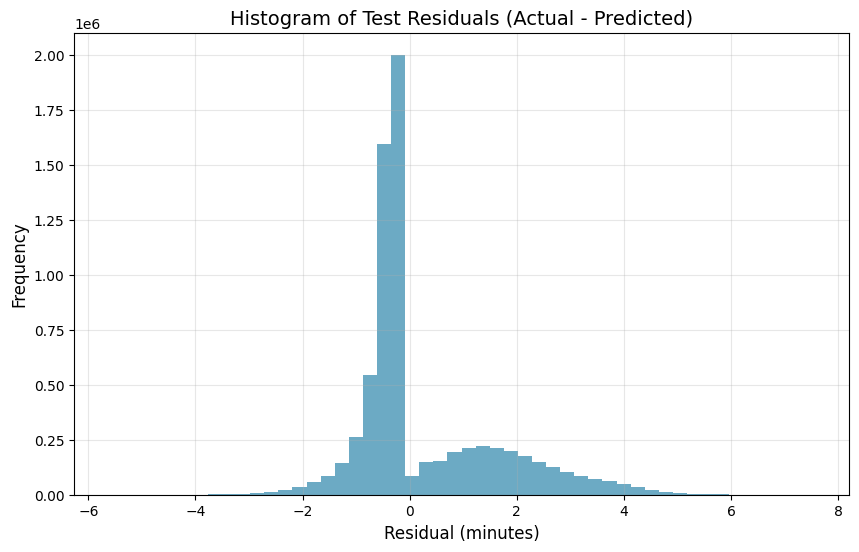

Min residual: -5.6097
Max residual: 7.5458
Max actuals: 7.9051
Max actuals: 0.0000
Max predicted: 6.9593
Max predicted: 0.0000


In [0]:
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load saved model
model_path = f"/dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018{add_to_path}.pth"
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)

# Recreate model architecture
embeddings_loaded, mlp_loaded, embedding_features_loaded = create_mlp_with_embeddings(
    dense_input_dim=checkpoint['dense_input_dim'],
    embedding_config=checkpoint['embedding_config'],
    hidden_dims=checkpoint['model_params']['hidden_dims'],
    dropout_rate=checkpoint['model_params']['dropout_rate']
)

# Load trained weights
embeddings_loaded.load_state_dict(checkpoint['embeddings_state_dict'])
mlp_loaded.load_state_dict(checkpoint['mlp_state_dict'])

print("Model loaded successfully!")

# Load test tensors
test_pickle_path = f"/dbfs/student-groups/Group_03_01/final_tensors{add_to_path_data}/test_2019.pkl"
with open(test_pickle_path, 'rb') as f:
    test_data = pickle.load(f)
X_test_dense = torch.FloatTensor(test_data['X_dense'])
X_test_embeddings = {k: torch.LongTensor(v) for k, v in test_data['X_embeddings'].items()}
y_test = torch.FloatTensor(test_data['y'])

# Move model to CPU
embeddings_loaded.eval()
mlp_loaded.eval()

# Prediction function
def forward_pass(embeddings, mlp, embedding_features, x_dense, x_embeddings):
    embedded_features = []
    for feat_name in embedding_features:
        emb = embeddings[feat_name](x_embeddings[feat_name])
        embedded_features.append(emb)
    if embedded_features:
        embeddings_concat = torch.cat(embedded_features, dim=1)
        x = torch.cat([x_dense, embeddings_concat], dim=1)
    else:
        x = x_dense
    return mlp(x)

# Batched prediction
batch_size = 4096
test_dataset = torch.utils.data.TensorDataset(X_test_dense, y_test)
test_indices = np.arange(len(X_test_dense))
test_preds = []
test_actuals = []

for i in range(0, len(test_indices), batch_size):
    idx = test_indices[i:i+batch_size]
    batch_dense = X_test_dense[idx]
    batch_embeddings = {k: v[idx] for k, v in X_test_embeddings.items()}
    with torch.no_grad():
        outputs = forward_pass(embeddings_loaded, mlp_loaded, embedding_features_loaded, batch_dense, batch_embeddings).squeeze()
    test_preds.append(outputs.cpu())
    test_actuals.append(y_test[idx].cpu())

test_preds_all = torch.cat(test_preds)
test_actuals_all = torch.cat(test_actuals)

# If needed, apply inverse log transform (if Log_DEP_DELAY is used)
# Otherwise, use raw values
residuals = (test_actuals_all - test_preds_all).numpy()

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='#2E86AB', alpha=0.7)
plt.title("Histogram of Test Residuals (Actual - Predicted)", fontsize=14)
plt.xlabel("Residual (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
display(plt.show())

print(f"Min residual: {residuals.min():.4f}")
print(f"Max residual: {residuals.max():.4f}")

print(f"Max actuals: {test_actuals_all.max():.4f}")
print(f"Max actuals: {test_actuals_all.min():.4f}")

print(f"Max predicted: {test_preds_all.max():.4f}")
print(f"Max predicted: {test_preds_all.min():.4f}")



In [0]:
# SHAP Visualization

In [0]:
def verify_threading():
    """Test if multi-threading actually works"""
    import torch
    import time
    
    # Small test
    X = torch.randn(5000, 500)
    W = torch.randn(500, 500)
    
    # Time with current settings
    start = time.time()
    for _ in range(100):
        Y = torch.matmul(X, W)
    elapsed = time.time() - start
    
    print(f"[Trial] 100 matrix multiplications: {elapsed:.2f} seconds")
    print(f"[Trial] PyTorch threads: {torch.get_num_threads()}")
    print(f"[Trial] OMP_NUM_THREADS: {os.environ.get('OMP_NUM_THREADS', 'not set')}")
    
    return elapsed

torch.set_num_threads(1)

# Call at start of trial
verify_threading()

[Trial] 100 matrix multiplications: 1.81 seconds
[Trial] PyTorch threads: 1
[Trial] OMP_NUM_THREADS: not set


1.8124921321868896

PYTORCH MULTITHREADING BENCHMARK TEST

Configuration:
  Sample fraction: 1.0%
  Epochs per test: 20
  Thread counts: [1, 4, 8, 16]

Sampling data from 2015-2017...
  Sampled 16,691 rows

Fitting and applying preprocessing pipeline...
Converting to PyTorch tensors...
Converted 16,683 samples to PyTorch tensors
Dense features shape: torch.Size([16683, 124])
Embedding features: 8
  Dense features: 124
  Embedding features: 8
  Samples: 16,683

Model configuration:
  Hidden layers: [128, 64]
  Batch size: 2048
  Embedding scale: 1.0

Train/val split:
  Train: 13,346 samples
  Val: 3,337 samples

RUNNING BENCHMARK

This will take approximately 1600 seconds...


Testing with 1 thread(s)
  PyTorch threads: 1
Epoch 1/20: Loss: 2.3720 | Train MAE: 12.19 | Val MAE: 19.40 | Train MAE_mod: 10.77 | Val MAE_mod: 13.23 | Train RMSE: 38.65 min | Val RMSE: 41.95 min | LR: 0.000220
Epoch 2/20: Loss: 2.3219 | Train MAE: 12.29 | Val MAE: 22.96 | Train MAE_mod: 10.91 | Val MAE_mod: 22.27 | Train RMSE: 42.0

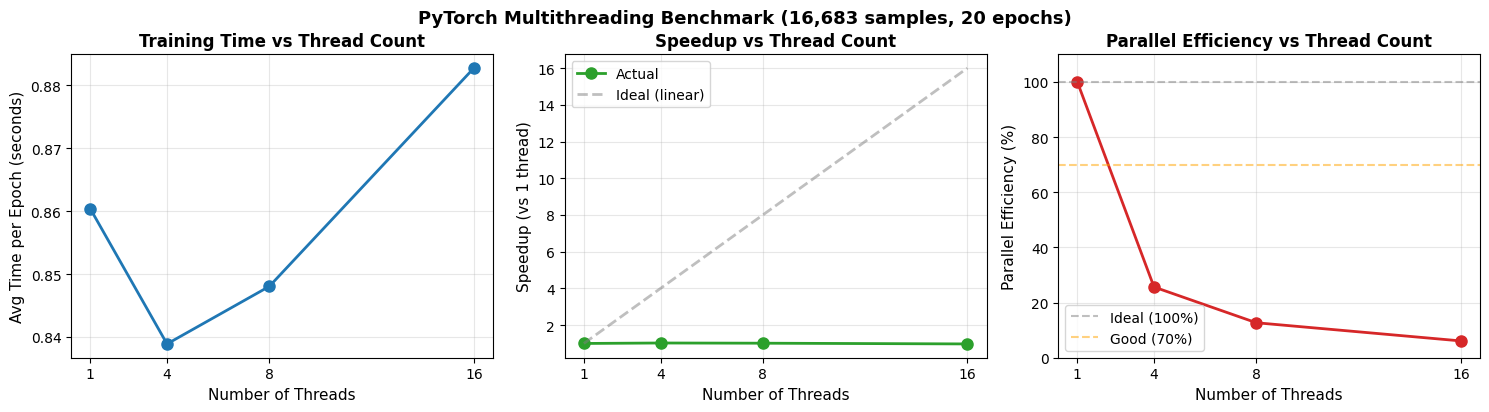


✓ Benchmark complete


In [0]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc
from pyspark.sql import functions as F

# ============================================================================
# PYTORCH MULTITHREADING BENCHMARK TEST
# ============================================================================
print("="*70)
print("PYTORCH MULTITHREADING BENCHMARK TEST")
print("="*70)

# Configuration
BENCHMARK_SAMPLE_FRACTION = 0.01  # 0.5% of data for fast benchmark
BENCHMARK_EPOCHS = 20  # Few epochs to measure speed
THREAD_COUNTS = [1, 4, 8, 16]  # Thread configurations to test

print(f"\nConfiguration:")
print(f"  Sample fraction: {BENCHMARK_SAMPLE_FRACTION*100:.1f}%")
print(f"  Epochs per test: {BENCHMARK_EPOCHS}")
print(f"  Thread counts: {THREAD_COUNTS}")

# Sample data from training period (2015-2017)
print(f"\nSampling data from 2015-2017...")
benchmark_data = data.filter(
    (F.col("YEAR") >= 2015) & (F.col("YEAR") <= 2017)
).sample(withReplacement=False, fraction=BENCHMARK_SAMPLE_FRACTION, seed=42)

benchmark_count = benchmark_data.count()
print(f"  Sampled {benchmark_count:,} rows")

# Apply preprocessing
print(f"\nFitting and applying preprocessing pipeline...")
benchmark_preprocessing_model = preprocessing_pipeline.fit(benchmark_data)
benchmark_processed = benchmark_preprocessing_model.transform(benchmark_data)

# Convert to PyTorch tensors
print(f"Converting to PyTorch tensors...")
X_dense_bench, X_embeddings_bench, y_bench = prepare_data_for_pytorch(benchmark_processed)

print(f"  Dense features: {X_dense_bench.shape[1]}")
print(f"  Embedding features: {len(X_embeddings_bench)}")
print(f"  Samples: {len(X_dense_bench):,}")

# Clean up Spark DataFrames
del benchmark_data, benchmark_processed
gc.collect()

# Get model configuration from best trial
add_to_path = "_log_embedding_weighted_sample_1pct"
results_path = f"/dbfs/student-groups/Group_03_01/ray_results{add_to_path}"

from ray import tune
import os

exp_dirs = [d for d in os.listdir(results_path) if d.startswith("ray_objective")]
latest_exp = sorted(exp_dirs)[-1]
exp_path = os.path.join(results_path, latest_exp)

analysis = tune.ExperimentAnalysis(exp_path)
best_trial = analysis.get_best_trial("rmse", "min", "last")
best_config = best_trial.config

# Setup model parameters (simplified for benchmark)
model_params = {
    'hidden_dims': [128, 64],  # Smaller for faster benchmark
    'dropout_rate': 0.3
}

training_params = {
    'learning_rate': best_config['learning_rate'],
    'batch_size': 2048,
    'num_epochs': BENCHMARK_EPOCHS,
    'patience': BENCHMARK_EPOCHS + 1,  # No early stopping
    'weight_decay': best_config['weight_decay']
}

# Get embedding config - use tuple format (vocab_size, embedding_dim)
embedding_scale_factor = best_config['embedding_scale_factor']
embedding_config_raw = EMBEDDING_CONFIGS_CORRECTED[embedding_scale_factor]
embedding_config_bench = {}
for feature in X_embeddings_bench.keys():
    vocab_size, embedding_dim = embedding_config_raw[feature]
    embedding_config_bench[feature] = (vocab_size, embedding_dim)  # Use tuple, not dict

print(f"\nModel configuration:")
print(f"  Hidden layers: {model_params['hidden_dims']}")
print(f"  Batch size: {training_params['batch_size']}")
print(f"  Embedding scale: {embedding_scale_factor}")

# Split into train/val for the benchmark (80/20 split)
split_idx = int(0.8 * len(X_dense_bench))
X_train_dense = X_dense_bench[:split_idx]
X_train_embeddings = {k: v[:split_idx] for k, v in X_embeddings_bench.items()}
y_train = y_bench[:split_idx]

X_val_dense = X_dense_bench[split_idx:]
X_val_embeddings = {k: v[split_idx:] for k, v in X_embeddings_bench.items()}
y_val = y_bench[split_idx:]

print(f"\nTrain/val split:")
print(f"  Train: {len(X_train_dense):,} samples")
print(f"  Val: {len(X_val_dense):,} samples")

# ============================================================================
# RUN BENCHMARK WITH DIFFERENT THREAD COUNTS
# ============================================================================
print(f"\n{'='*70}")
print("RUNNING BENCHMARK")
print("="*70)
print(f"\nThis will take approximately {len(THREAD_COUNTS) * BENCHMARK_EPOCHS * 20} seconds...\n")

benchmark_results = []

for num_threads in THREAD_COUNTS:
    print(f"\n{'='*70}")
    print(f"Testing with {num_threads} thread(s)")
    print(f"{'='*70}")
    
    # Set thread count
    torch.set_num_threads(num_threads)
    print(f"  PyTorch threads: {torch.get_num_threads()}")
    
    # Measure training time
    start_time = time.time()
    
    result = train_pytorch_distributed(
        model_params,
        training_params,
        (X_train_dense, X_train_embeddings, y_train),  # Keep as tensors
        (X_val_dense, X_val_embeddings, y_val),  # Keep as tensors
        embedding_config_bench,
        use_bias_correction=USE_BIAS_CORRECTION,
        use_weighted_loss=USE_WEIGHTED_LOSS,
        loss_weight_alpha=best_config['loss_weight_alpha']
    )
    
    total_time = time.time() - start_time
    avg_epoch_time = total_time / BENCHMARK_EPOCHS
    
    benchmark_results.append({
        'threads': num_threads,
        'total_time': total_time,
        'avg_epoch_time': avg_epoch_time,
        'val_rmse': result['val_rmse']
    })
    
    print(f"\nResults:")
    print(f"  Total time: {total_time:.2f} seconds")
    print(f"  Avg time per epoch: {avg_epoch_time:.2f} seconds")
    print(f"  Val RMSE: {result['val_rmse']:.4f} minutes")
    
    if len(benchmark_results) > 1:
        baseline_time = benchmark_results[0]['avg_epoch_time']
        speedup = baseline_time / avg_epoch_time
        efficiency = (speedup / num_threads) * 100
        print(f"  Speedup vs 1 thread: {speedup:.2f}x")
        print(f"  Parallel efficiency: {efficiency:.1f}%")
    
    # Cleanup
    gc.collect()

print(f"\n{'='*70}")
print("BENCHMARK COMPLETE")
print(f"{'='*70}")

# ============================================================================
# VISUALIZE RESULTS
# ============================================================================
threads = [r['threads'] for r in benchmark_results]
avg_times = [r['avg_epoch_time'] for r in benchmark_results]
baseline_time = benchmark_results[0]['avg_epoch_time']
speedups = [baseline_time / t for t in avg_times]
efficiencies = [(speedups[i] / threads[i]) * 100 for i in range(len(threads))]

# Summary table
print("\n" + "="*70)
print("BENCHMARK SUMMARY")
print("="*70)
print(f"\n{'Threads':<10} {'Avg Time (s)':<15} {'Speedup':<12} {'Efficiency':<12}")
print("-"*70)
for i in range(len(threads)):
    print(f"{threads[i]:<10} {avg_times[i]:<15.2f} {speedups[i]:<12.2f}x {efficiencies[i]:<12.1f}%")

# Recommendations
print(f"\n{'='*70}")
print("RECOMMENDATIONS")
print("="*70)

optimal_idx = 0
for i in range(len(threads)):
    if efficiencies[i] >= 70 and speedups[i] > speedups[optimal_idx]:
        optimal_idx = i

optimal_threads = threads[optimal_idx]
optimal_speedup = speedups[optimal_idx]
optimal_efficiency = efficiencies[optimal_idx]

print(f"\nOptimal configuration: {optimal_threads} threads")
print(f"  Speedup: {optimal_speedup:.2f}x")
print(f"  Efficiency: {optimal_efficiency:.1f}%")
print(f"  Time reduction: {(1 - 1/optimal_speedup)*100:.1f}%")

if optimal_threads < max(threads):
    print(f"\n⚠ Note: Using {max(threads)} threads shows diminishing returns")
    print(f"   Efficiency drops to {efficiencies[-1]:.1f}% due to overhead")
else:
    print(f"\n✓ Maximum threads ({max(threads)}) provides best performance")

print(f"\n{'='*70}\n")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training time
axes[0].plot(threads, avg_times, 'o-', linewidth=2, markersize=8, color='#1f77b4')
axes[0].set_xlabel('Number of Threads', fontsize=11)
axes[0].set_ylabel('Avg Time per Epoch (seconds)', fontsize=11)
axes[0].set_title('Training Time vs Thread Count', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(threads)

# Plot 2: Speedup
axes[1].plot(threads, speedups, 'o-', linewidth=2, markersize=8, color='#2ca02c', label='Actual')
axes[1].plot(threads, threads, '--', linewidth=2, color='gray', alpha=0.5, label='Ideal (linear)')
axes[1].set_xlabel('Number of Threads', fontsize=11)
axes[1].set_ylabel('Speedup (vs 1 thread)', fontsize=11)
axes[1].set_title('Speedup vs Thread Count', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(threads)

# Plot 3: Efficiency
axes[2].plot(threads, efficiencies, 'o-', linewidth=2, markersize=8, color='#d62728')
axes[2].axhline(y=100, linestyle='--', color='gray', alpha=0.5, label='Ideal (100%)')
axes[2].axhline(y=70, linestyle='--', color='orange', alpha=0.5, label='Good (70%)')
axes[2].set_xlabel('Number of Threads', fontsize=11)
axes[2].set_ylabel('Parallel Efficiency (%)', fontsize=11)
axes[2].set_title('Parallel Efficiency vs Thread Count', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(threads)
axes[2].set_ylim([0, 110])

plt.tight_layout()
plt.suptitle(f'PyTorch Multithreading Benchmark ({len(X_dense_bench):,} samples, {BENCHMARK_EPOCHS} epochs)', 
             fontsize=13, fontweight='bold', y=1.02)
display(plt.show())

print(f"\n✓ Benchmark complete")